<a href="https://colab.research.google.com/github/HudaSaffo/fashion-recommendation-system/blob/week7_collage_composition/collage_composition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 — Collage Composition Algorithm

This notebook converts the recommended outfit sets from Week 6 into visually balanced collages using the transparent product cutouts from Week 3. It assigns item positions and sizes by category, preserves image proportions, checks for unwanted overlap, and exports the final collage with a transparent background.

The rule-based layout provides the MVP composition. An optional search evaluates 50–200 layout variations using visual balance, category placement, overlap, empty space, and hero-item prominence, then selects the highest-scoring valid layout.

## 1. Setup

Import the required tools and set the output folder. In Colab, connect Google Drive to access the real cutouts.

In [12]:
import sys
from pathlib import Path
from IPython.display import display
IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd()
OUT = (Path('/content/drive/MyDrive/week7_two_column') if IN_COLAB
       else ROOT / 'outputs' / 'week7_two_column')
OUT.mkdir(parents=True, exist_ok=True)

## 2. Collage algorithm

Define image loading, layout scoring, validation, and transparent rendering. Separates keep the top left, trousers right, accessories below the top, and shoes below the trousers; other outfit types use alternative templates.

In [6]:
from __future__ import annotations
import csv
import json
import math
import random
from dataclasses import asdict, dataclass, field
from pathlib import Path
from collections.abc import Mapping
from PIL import Image, ImageChops, ImageDraw, ImageFont

ALIASES = {'top': 'tops', 'bottom': 'bottoms', 'dress': 'dresses',
           'bag': 'bags', 'accessory': 'accessories', 'shoe': 'shoes'}

REGIONS = {'tops': (.13, .17, .44, .35), 'bottoms': (.14, .55, .40, .40),
           'dresses': (.14, .17, .43, .78), 'shoes': (.64, .79, .30, .16),
           'bags': (.66, .46, .25, .24), 'accessories': (.69, .19, .18, .15),
           'outerwear': (.035, .145, .56, .38)}

ORDER = ('outerwear', 'tops', 'dresses', 'bottoms', 'bags', 'accessories', 'shoes')

COMPONENTS = ('visual_balance_score', 'category_layout_score', 'overlap_penalty',
              'empty_space_penalty', 'hero_item_prominence')

@dataclass(frozen=True)
class ScoreWeights:
    visual_balance_score: float = 25
    category_layout_score: float = 25
    overlap_penalty: float = 80
    empty_space_penalty: float = 20
    hero_item_prominence: float = 25

@dataclass
class Item:
    product_id: str
    category: str
    image: Image.Image
    cutout_path: str = ''
    title: str = ''

def read_manifest(path):
    path = Path(path)
    with path.open(newline='', encoding='utf-8-sig') as stream:
        reader = csv.DictReader(stream)
        if not {'item_id', 'cutout_path', 'quality_valid'} <= set(reader.fieldnames or []):
            raise ValueError('Manifest requires item_id, cutout_path, quality_valid columns')
        records = {}
        for row in reader:
            pid = row['item_id'].strip()
            if not pid or pid in records:
                raise ValueError(f'Blank or duplicate manifest item_id: {pid!r}')
            row['cutout_path'] = row['cutout_path'].strip()
            if row['cutout_path'] and not Path(row['cutout_path']).is_absolute():
                row['cutout_path'] = str(path.parent / row['cutout_path'])
            records[pid] = row
    return records

def load_items(outfit, cutout_dir=None, manifest_path=None):
    if not isinstance(outfit, Mapping) or not isinstance(outfit.get('items'), Mapping):
        raise ValueError('Expected one Week 6 outfit with an items mapping')
    manifest = read_manifest(manifest_path) if manifest_path is not None else None
    items, seen, categories = [], set(), set()
    for slot, product in outfit['items'].items():
        category = ALIASES.get(slot, slot)
        if category not in REGIONS or category in categories:
            raise ValueError(f'Unsupported or duplicate category: {slot}')
        categories.add(category)
        if not isinstance(product, Mapping) or not str(product.get('product_id', '')).strip():
            raise ValueError(f'{slot}: expected a product with product_id')
        raw_id = product['product_id']
        if raw_id is None or isinstance(raw_id, (float, bool)):
            raise ValueError(f'{slot}: product_id must be a string or integer')
        pid = str(raw_id).strip()
        if pid in seen:
            raise ValueError(f'Duplicate product: {pid}')
        seen.add(pid)
        row = None
        if manifest is not None:
            row = manifest.get(pid)
            if row is None:
                raise ValueError(f'{pid}: missing from segmentation manifest')
            if str(row['quality_valid']).strip().lower() not in ('true', '1'):
                raise ValueError(f'{pid}: Week 3 quality_valid is not true')
        if cutout_dir is not None:
            if any(char in pid for char in '/\\:') or pid in ('.', '..'):
                raise ValueError(f'Unsafe filename product_id: {pid}')
            path = Path(cutout_dir) / f'{pid}.png'
        else:
            path = row['cutout_path'] if row is not None else product.get('cutout_path')
        if not path:
            raise ValueError(f'{pid}: supply a Week 3 manifest, cutout_dir or cutout_path')
        try:
            with Image.open(path) as source:
                image = source.convert('RGBA')
        except OSError as exc:
            raise ValueError(f'{pid}: cannot read cutout {path}') from exc
        alpha = image.getchannel('A')
        box = alpha.getbbox()
        if box is None or alpha.getextrema()[0] == 255:
            raise ValueError(f'{pid}: expected a nonempty transparent cutout')
        items.append(Item(pid, category, image.crop(box), str(path), str(product.get('title', ''))))
    if not items:
        raise ValueError('The outfit is empty')
    if 'dresses' in categories and categories & {'tops', 'bottoms'}:
        raise ValueError('A dress replaces tops and bottoms; fix the input outfit')
    return sorted(items, key=lambda item: ORDER.index(item.category))

def _alpha_mass(image):
    return sum(value * count for value, count in enumerate(image.histogram())) / 255

def _pixel_box(p, size):
    return (round(p['x'] * size), round(p['y'] * size),
            max(1, round(p['width'] * size)), max(1, round(p['height'] * size)))

def _masks(items, placements, size):
    masks = []
    for item, p in zip(items, placements):
        x, y, w, h = _pixel_box(p, size)
        mask = Image.new('L', (size, size))
        mask.paste(item.image.getchannel('A').resize((w, h), Image.Resampling.LANCZOS), (x, y))
        masks.append(mask)
    return masks

def _intentional(a, b):
    return 'outerwear' in {a, b} and bool({a, b} & {'tops', 'dresses'})

def _draw_title(canvas, title, config):
    if not isinstance(title, str) or '\n' in title or '\r' in title:
        raise ValueError('Title must be a single-line string')
    if not title:
        return
    size = canvas.width
    draw = ImageDraw.Draw(canvas)
    for font_size in range(round(size*.032), 7, -1):
        font = ImageFont.load_default(size=font_size)
        box = draw.textbbox((0, 0), title, font=font)
        if box[2]-box[0] <= size*.88 and box[3]-box[1] <= size*config.title_bottom*.65:
            draw.text((size*.06-box[0], size*config.title_bottom*.5-(box[3]-box[1])/2-box[1]),
                      title, font=font, fill='#26332e')
            return
    raise ValueError('Title is too long for the reserved title area')

@dataclass(frozen=True)
class LayoutConfig:
    weights: ScoreWeights = field(default_factory=lambda: ScoreWeights(30, 25, 90, 35, 30))
    scoring_size: int = 160
    title_bottom: float = .13
    margin: float = .07
    item_gap: float = .026
    column_gap: float = .035
    maximum_support_gap: float = .065
    shoe_max_width: float = .22
    shoe_max_height: float = .14
    shoe_hero_length_ratio: float = .56
    bag_max_width: float = .21
    bag_max_height: float = .22
    bag_hero_length_ratio: float = .62
    accessory_max_width: float = .13
    accessory_max_height: float = .13
    accessory_hero_length_ratio: float = .36
    support_hero_area_ratio: float = .62
    minimum_outerwear_visible: float = .20
    intentional_overlap_allowance: float = .68
    outerwear_area_ratio: float = 1.12
    board_column_gap: float = .14
    board_row_gap: float = .065
    board_top_max_width: float = .28
    board_top_max_height: float = .35
    board_bottom_max_width: float = .25
    board_bottom_max_height: float = .47
    board_bottom_height_ratio: float = 1.15

    def __post_init__(self):
        for name, value in asdict(self.weights).items():
            if not math.isfinite(value) or value < 0:
                raise ValueError(f'{name} must be finite and nonnegative')
        if not isinstance(self.scoring_size, int) or not 64 <= self.scoring_size <= 256:
            raise ValueError('scoring_size must be an integer from 64 to 256')
        for name, value in asdict(self).items():
            if name in ('weights', 'scoring_size'):
                continue
            if not isinstance(value, (float, int)) or not math.isfinite(value) or value <= 0:
                raise ValueError(f'{name} must be finite and positive')
        if not .04 <= self.margin <= .15 or not .08 <= self.title_bottom <= .2:
            raise ValueError('Use margin .04–.15 and title_bottom .08–.20')
        if not .01 <= self.item_gap <= .06 or not .015 <= self.column_gap <= .08:
            raise ValueError('Use item_gap .01–.06 and column_gap .015–.08')
        if self.maximum_support_gap < self.item_gap*1.15 or self.maximum_support_gap > .15:
            raise ValueError('maximum_support_gap must be >= 1.15*item_gap and <= .15')
        for name in ('shoe_max_width','shoe_max_height','bag_max_width','bag_max_height',
                     'accessory_max_width','accessory_max_height'):
            if not .02 <= getattr(self,name) <= .35:
                raise ValueError(f'{name} must be .02–.35')
        for name in ('shoe_hero_length_ratio','bag_hero_length_ratio','accessory_hero_length_ratio',
                     'support_hero_area_ratio','minimum_outerwear_visible','intentional_overlap_allowance'):
            if not 0 < getattr(self,name) <= 1:
                raise ValueError(f'{name} must be in (0, 1]')
        if not 1 <= self.outerwear_area_ratio <= 1.3:
            raise ValueError('outerwear_area_ratio must be 1–1.3')
        if not .08 <= self.board_column_gap <= .24 or not .04 <= self.board_row_gap <= .12:
            raise ValueError('Board column gap must be .08–.24 and row gap .04–.12')
        if not 1.05 <= self.board_bottom_height_ratio <= 1.5:
            raise ValueError('Bottom height ratio must be 1.05–1.5')
        for name in ('board_top_max_width','board_top_max_height',
                     'board_bottom_max_width','board_bottom_max_height'):
            if not .10 <= getattr(self,name) <= .60:
                raise ValueError(f'{name} must be .10–.60')


def _primary(items):
    return next(i for cat in ('tops','dresses','bottoms','outerwear','bags','shoes','accessories')
                for i in items if i.category == cat)


def _fit(item, width, height):
    factor = min(width/item.image.width, height/item.image.height)
    return item.image.width*factor, item.image.height*factor


def _coverage(item):
    return _alpha_mass(item.image.getchannel('A'))/(item.image.width*item.image.height)


def available_templates(items):
    categories = {i.category for i in items}
    if not categories & {'tops','dresses','bottoms','outerwear'}:
        return ['accessory_cluster', 'accessory_steps'] if len(items)>1 else ['single_focus']
    prefix = 'dress' if 'dresses' in categories else 'separates'
    if categories & {'bags','accessories','shoes'}:
        return [prefix+'_side_stack', prefix+'_staggered', prefix+'_shelf']
    return [prefix+'_centered', prefix+'_offset']


def _support_limits(category, config):
    prefix = {'shoes':'shoe', 'bags':'bag', 'accessories':'accessory'}[category]
    return (getattr(config,prefix+'_max_width'), getattr(config,prefix+'_max_height'),
            getattr(config,prefix+'_hero_length_ratio'))


def _placements(items, template, rng, config, baseline=False):
    """Pack only present categories. Gaps are between actual trimmed boxes."""
    primary = _primary(items)
    bycat = {i.category:i for i in items}
    clothing = primary.category in ('tops','dresses','bottoms','outerwear')
    primary_bounds = {'tops':(.39,.355), 'dresses':(.38,.66), 'bottoms':(.33,.53),
                      'outerwear':(.40,.53), 'bags':(.25,.29), 'shoes':(.28,.18),
                      'accessories':(.18,.22)}
    scale = 1 if baseline else rng.uniform(.92,1.04)
    pw, ph = _fit(primary, *(v*scale for v in primary_bounds[primary.category]))
    dimensions = {primary.category:(pw,ph)}
    hero_area = pw*ph*_coverage(primary)
    for item in items:
        cat = item.category
        if item is primary:
            continue
        if cat == 'bottoms':
            w,h = _fit(item,.30*scale,.34*scale)
            factor = min(1,math.sqrt(.90*hero_area/max(1e-12,w*h*_coverage(item))))
            w,h = w*factor,h*factor
        elif cat == 'outerwear':
            w,h = _fit(item,pw*1.28,ph*1.035)
            factor = min(1,math.sqrt(config.outerwear_area_ratio*pw*ph/(w*h)))
            w,h = w*factor,h*factor
        else:
            maxw,maxh,ratio = _support_limits(cat,config)
            cap = max(pw,ph)*ratio if clothing else max(maxw,maxh)
            w,h = _fit(item,min(maxw,cap),min(maxh,cap))
            factor = min(1, math.sqrt(config.support_hero_area_ratio*hero_area/max(1e-12,w*h*_coverage(item)))) if clothing else 1
            jitter = 1 if baseline else rng.uniform(.89,1)
            w,h = w*factor*jitter,h*factor*jitter
        dimensions[cat]=(w,h)
    gap = config.item_gap*(1 if baseline else rng.uniform(.92,1.12))
    colgap = config.column_gap*(1 if baseline else rng.uniform(.90,1.12))
    pos = {primary.category:(0.,0.)}
    leftwidth = pw
    mainheight = ph
    if primary.category == 'tops' and 'bottoms' in bycat:
        bw,bh = dimensions['bottoms']
        shift = .022 if template.endswith('_staggered') or template.endswith('_offset') else 0
        pos['bottoms']=((pw-bw)/2+shift,ph+gap)
        mainheight=ph+gap+bh
        leftwidth=max(pw,pos['bottoms'][0]+bw)
    if 'outerwear' in bycat and primary.category != 'outerwear':
        ow,oh = dimensions['outerwear']
        pos['outerwear']=(-min(.075,pw*.30),-.015)
    supports = [c for c in ('accessories','bags','shoes') if c in bycat and c != primary.category]
    if not clothing:
        allcats = [c for c in ('accessories','bags','shoes') if c in bycat]
        x=0
        for index,cat in enumerate(allcats):
            w,h=dimensions[cat]
            y=(max(v[1] for v in dimensions.values())-h)/2
            if template=='accessory_steps': y+=index*.025
            pos[cat]=(x,y)
            x+=w+gap
    elif supports:
        if template.endswith('_shelf') and 'shoes' in supports and len(supports)>1:
            uppers=[c for c in supports if c!='shoes']
            uw=sum(dimensions[c][0] for c in uppers)+gap*(len(uppers)-1)
            uh=max(dimensions[c][1] for c in uppers)
            sh=dimensions['shoes'][1]
            cluster_h=uh+gap+sh
            cluster_w=max(uw,dimensions['shoes'][0])
            sy=max(0,mainheight*.66-cluster_h/2)
            sy=min(sy,max(0,mainheight-cluster_h))
            cursor=leftwidth+colgap+(cluster_w-uw)/2
            for cat in uppers:
                w,h=dimensions[cat]
                pos[cat]=(cursor,sy+(uh-h)/2)
                cursor+=w+gap
            pos['shoes']=(leftwidth+colgap+(cluster_w-dimensions['shoes'][0])/2,sy+uh+gap)
        else:
            heights=sum(dimensions[c][1] for c in supports)+gap*(len(supports)-1)
            sw=max(dimensions[c][0] for c in supports)
            anchor=.65 if not template.endswith('_staggered') else .70
            sy=min(max(0,mainheight*anchor-heights/2),max(0,mainheight-heights))
            for index,cat in enumerate(supports):
                w,h=dimensions[cat]
                stagger=(.015 if index%2 else 0) if template.endswith('_staggered') else 0
                pos[cat]=(leftwidth+colgap+(sw-w)/2+stagger,sy)
                sy+=h+gap
    minx=min(pos[c][0] for c in pos); miny=min(pos[c][1] for c in pos)
    maxx=max(pos[c][0]+dimensions[c][0] for c in pos)
    maxy=max(pos[c][1]+dimensions[c][1] for c in pos)
    gw,gh=maxx-minx,maxy-miny
    usable_h=1-config.title_bottom-2*config.margin
    overall=min(1,(1-2*config.margin)/gw,usable_h/gh)
    gx=(1-gw*overall)/2
    gy=config.title_bottom+config.margin+(usable_h-gh*overall)/2
    placements=[]
    for item in items:
        x,y=pos[item.category]; w,h=dimensions[item.category]
        placements.append(dict(product_id=item.product_id,category=item.category,
            x=gx+(x-minx)*overall,y=gy+(y-miny)*overall,width=w*overall,height=h*overall))
    return placements


def _box_gap(a,b):
    dx=max(a['x']-b['x']-b['width'],b['x']-a['x']-a['width'],0)
    dy=max(a['y']-b['y']-b['height'],b['y']-a['y']-a['height'],0)
    return math.hypot(dx,dy)


def _support_pairs(items, placements):
    primary=_primary(items)
    supports=[p for p in placements if p['category'] in ('accessories','bags','shoes')]
    if len(supports)<2: return []
    connected={0}; edges=[]
    while len(connected)<len(supports):
        _,a,b=min((_box_gap(supports[a],supports[b]),a,b)
                  for a in connected for b in range(len(supports)) if b not in connected)
        edges.append((supports[a],supports[b]))
        connected.add(b)
    return edges


def _proportion_errors(items, placements, config):
    errors=[]
    primary=_primary(items)
    if primary.category not in ('tops','dresses','bottoms','outerwear'):
        return errors
    hp=next(p for p in placements if p['product_id']==primary.product_id)
    area=hp['width']*hp['height']*_coverage(primary)
    byid={i.product_id:i for i in items}
    for p in placements:
        cat=p['category']
        if cat not in ('bags','accessories','shoes'):
            continue
        maxw,maxh,ratio=_support_limits(cat,config)
        if p['width']>maxw+1e-9 or p['height']>maxh+1e-9:
            errors.append(f'{cat}: exceeds canvas size cap')
        if max(p['width'],p['height'])>ratio*max(hp['width'],hp['height'])+1e-9:
            errors.append(f'{cat}: too large relative to hero')
        if p['width']*p['height']*_coverage(byid[p['product_id']])>config.support_hero_area_ratio*area+1e-9:
            errors.append(f'{cat}: visible area exceeds supporting-item limit')
    return errors


def validate_layout(items, placements, size=1200, config=None):
    config=config or LayoutConfig()
    if not items or len(items)!=len(placements):
        return ['Expected exactly one placement per item']
    errors=[]
    if [i.category for i in items]!=sorted((i.category for i in items),key=ORDER.index):
        return ['Items must be in back-to-front category order']
    for item,p in zip(items,placements):
        if (p.get('product_id'),p.get('category'))!=(item.product_id,item.category):
            return ['Placement identity/order mismatch']
        if any(not isinstance(p.get(k),(int,float)) or not math.isfinite(p[k]) for k in ('x','y','width','height')):
            return ['Invalid placement geometry']
        x,y,w,h=_pixel_box(p,size)
        if min(p['width'],p['height'])*size<1:
            errors.append(f'{item.product_id}: too thin to render')
        if x<0 or y<math.ceil(config.title_bottom*size) or x+w>size or y+h>size:
            errors.append(f'{item.product_id}: outside canvas or in title area')
        if p['height']<=0 or not math.isclose(p['width']/p['height'],item.image.width/item.image.height,rel_tol=1e-9):
            errors.append(f'{item.product_id}: changed aspect ratio')
    if errors: return errors
    errors.extend(_proportion_errors(items,placements,config))
    pairs=_support_pairs(items,placements)
    for a,b in pairs:
        if _box_gap(a,b)>config.maximum_support_gap:
            errors.append(f'{a["product_id"]}/{b["product_id"]}: disconnected supporting items')
    masks=_masks(items,placements,size)
    for a in range(len(items)):
        for b in range(a+1,len(items)):
            if not _intentional(items[a].category,items[b].category):
                if ImageChops.darker(masks[a],masks[b]).getbbox():
                    errors.append(f'Unintended overlap: {items[a].product_id}/{items[b].product_id}')
    for n,item in enumerate(items):
        if item.category=='outerwear':
            visible=masks[n]
            for higher in masks[n+1:]:
                visible=ImageChops.multiply(visible,ImageChops.invert(higher))
            if _alpha_mass(visible)/max(1e-12,_alpha_mass(masks[n]))<config.minimum_outerwear_visible:
                errors.append('Outerwear is excessively hidden')
    return errors


def _largest_empty_fraction(mask):
    box=mask.getbbox()
    if box is None: return 1.
    crop=mask.crop(box)
    w,h=crop.size
    data=crop.tobytes(); heights=[0]*w; best=0
    for y in range(h):
        for x in range(w):
            heights[x]=heights[x]+1 if data[y*w+x]<12 else 0
        stack=[]
        for x in range(w+1):
            height=heights[x] if x<w else 0
            start=x
            while stack and stack[-1][1]>height:
                start,previous=stack.pop()
                best=max(best,previous*(x-start))
            stack.append((start,height))
    return best/(w*h)


def score_layout(items, placements, config=None):
    config=config or LayoutConfig()
    if not items or len(items)!=len(placements):
        raise ValueError('Expected one placement per item')
    size=config.scoring_size
    masks=_masks(items,placements,size)
    mass=[_alpha_mass(m) for m in masks]
    union=Image.new('L',(size,size))
    for m in masks: union=ImageChops.screen(union,m)
    data=union.tobytes(); total=sum(data)
    if not total: raise ValueError('Layout is invisible at scoring resolution')
    cx=sum((k%size+.5)*v for k,v in enumerate(data))/(size*total)
    cy=sum((k//size+.5)*v for k,v in enumerate(data))/(size*total)
    balance=max(0,1-math.hypot(cx-.5,cy-(1+config.title_bottom)/2)/.40)
    visible=[]
    for n,m in enumerate(masks):
        for upper in masks[n+1:]: m=ImageChops.multiply(m,ImageChops.invert(upper))
        visible.append(_alpha_mass(m)/(size*size))
    overlap=0.; pairs=[]
    for a in range(len(items)):
        for b in range(a+1,len(items)):
            inter=_alpha_mass(ImageChops.darker(masks[a],masks[b]))
            frac=inter/max(1e-12,min(mass[a],mass[b]))
            intentional=_intentional(items[a].category,items[b].category)
            overlap+=max(0,frac-config.intentional_overlap_allowance) if intentional else frac
            if inter: pairs.append(dict(items=[items[a].product_id,items[b].product_id],fraction=frac,intentional=intentional))
    bycat={p['category']:p for p in placements}
    primary=_primary(items)
    hp=bycat[primary.category]
    checks=[]
    if 'tops' in bycat and 'bottoms' in bycat:
        a,b=bycat['tops'],bycat['bottoms']
        checks.extend([float(b['y']>=a['y']+a['height']),max(0,1-abs(b['x']+b['width']/2-a['x']-a['width']/2)/.15)])
    if primary.category in ('tops','dresses','bottoms','outerwear'):
        for cat in ('bags','accessories','shoes'):
            if cat in bycat:
                p=bycat[cat]
                checks.append(float(p['x']+p['width']/2>hp['x']+hp['width']/2))
        if 'shoes' in bycat:
            p=bycat['shoes']; low=max(q['y']+q['height'] for q in placements)
            checks.append(min(1,max(0,(p['y']+p['height']/2-hp['y'])/max(.01,(low-hp['y'])*.62))))
    adherence=sum(checks)/len(checks) if checks else 1.
    gaps=[min((_box_gap(p,q) for q in placements if q is not p),default=0) for p in placements]
    support_pairs=_support_pairs(items,placements)
    support_gaps=[_box_gap(a,b) for a,b in support_pairs]
    box=union.getbbox(); group_area=(box[2]-box[0])*(box[3]-box[1])
    occupancy=(total/255)/group_area
    largest_hole=_largest_empty_fraction(union)
    group_gap=sum(max(0,g-config.column_gap)/.10 for g in gaps)/len(gaps)
    internal_gap=sum(max(0,g-config.item_gap)/.12 for g in support_gaps)/max(1,len(support_gaps))
    empty=.30*max(0,.52-occupancy)/.52+.30*largest_hole+.20*group_gap+.20*internal_gap
    hero=next((n for n,i in enumerate(items) if i.category in ('tops','dresses')),None)
    prominence=0.
    if hero is not None:
        other=max((a for n,a in enumerate(visible) if n!=hero and items[n].category!='outerwear'),default=0)
        prominence=min(1,visible[hero]/max(1e-12,1.10*other))
        oversize=0.
        for cat in ('shoes','bags','accessories'):
            if cat in bycat:
                p=bycat[cat]; _,_,ratio=_support_limits(cat,config)
                oversize+=max(0,max(p['width'],p['height'])/(ratio*max(hp['width'],hp['height']))-1)
        prominence-=oversize
    raw=dict(visual_balance_score=balance,category_layout_score=adherence,
             overlap_penalty=-overlap,empty_space_penalty=-empty,hero_item_prominence=prominence)
    components={k:raw[k]*getattr(config.weights,k) for k in COMPONENTS}
    return dict(collage_score=sum(components.values()),**components,
        measurements=dict(visual_centroid=[cx,cy],group_occupancy=occupancy,
            largest_internal_empty_rectangle=largest_hole,nearest_item_gaps=gaps,
            support_pair_gaps=support_gaps,overlap_pairs=pairs,
            visible_item_areas={i.product_id:a for i,a in zip(items,visible)}))


def compose(outfit, output_path, cutout_dir=None, title='Your outfit', candidates=100,
            seed=7, size=1200, manifest_path=None, config=None):
    config=config or LayoutConfig()
    if not isinstance(candidates,int) or (candidates!=1 and not 50<=candidates<=200):
        raise ValueError('Use candidates=1 or 50–200')
    if not isinstance(size,int) or not 256<=size<=4096:
        raise ValueError('Canvas size must be an integer from 256 to 4096')
    if not isinstance(seed,int): raise ValueError('seed must be an integer')
    output=Path(output_path)
    if output.suffix.lower()!='.png': raise ValueError('Output must be a PNG')
    items=load_items(outfit,cutout_dir,manifest_path)
    rng=random.Random(seed)
    templates=available_templates(items)
    options=[]
    for n in range(candidates):
        template=templates[n%len(templates)]
        layout=_placements(items,template,rng,config,baseline=n<len(templates))
        options.append((score_layout(items,layout,config),layout,template,n))
    baseline_errors=validate_layout(items,options[0][1],size,config)
    selected=None; rejected=[]
    for option in sorted(options,key=lambda r:(-r[0]['collage_score'],r[3])):
        errors=validate_layout(items,option[1],size,config)
        if errors: rejected.append(dict(candidate_index=option[3],errors=errors))
        else:
            selected=option
            break
    if selected is None: raise ValueError(f'No valid layout: {rejected[0]["errors"]}')
    score,layout,template,index=selected
    canvas=Image.new('RGBA',(size,size),(0,0,0,0))
    _draw_title(canvas,title,config)
    placed=[]
    for item,p in zip(items,layout):
        x,y,w,h=_pixel_box(p,size)
        canvas.alpha_composite(item.image.resize((w,h),Image.Resampling.LANCZOS),(x,y))
        placed.append(dict(p,pixel_box_xywh=[x,y,w,h],trimmed_size=list(item.image.size),
                           cutout_path=item.cutout_path,title=item.title))
    result=dict(schema_version=3,title=title,score=score,placements=placed,
        candidates=candidates,templates_evaluated=templates[:min(candidates,len(templates))],
        selected_template=template,selected_candidate_index=index,seed=seed,canvas_size=size,
        baseline_score=options[0][0]['collage_score'],baseline_valid=not baseline_errors,
        validation_errors=[],rejected_higher_ranked_candidates=rejected,config=asdict(config),
        input_provenance=outfit.get('provenance','caller-supplied outfit'),
        manifest_path=str(manifest_path) if manifest_path else None)
    output.parent.mkdir(parents=True,exist_ok=True)
    canvas.save(output,format='PNG')
    output.with_suffix('.json').write_text(json.dumps(result,indent=2,allow_nan=False),encoding='utf-8')
    return result

_adaptive_templates = available_templates
_adaptive_placements = _placements
_adaptive_support_pairs = _support_pairs
_adaptive_validate = validate_layout
_adaptive_score = score_layout


def _is_board(items):
    return {'tops','bottoms'} <= {i.category for i in items}


def available_templates(items):
    if _is_board(items):
        return ['board_balanced','board_airy','board_tailored']
    return _adaptive_templates(items)


def _placements(items, template, rng, config, baseline=False):
    if not _is_board(items):
        return _adaptive_placements(items,template,rng,config,baseline)
    bycat={i.category:i for i in items}
    scale=1 if baseline else rng.uniform(.94,1.02)
    tw,th=_fit(bycat['tops'],config.board_top_max_width*scale,config.board_top_max_height*scale)
    bw,bh=_fit(bycat['bottoms'],config.board_bottom_max_width*scale,config.board_bottom_max_height*scale)
    shrink=min(1,bh/(config.board_bottom_height_ratio*th))
    tw,th=tw*shrink,th*shrink
    dims={'tops':(tw,th),'bottoms':(bw,bh)}
    hero_area=tw*th*_coverage(bycat['tops'])
    for cat in ('accessories','bags','shoes'):
        if cat not in bycat: continue
        maxw,maxh,ratio=_support_limits(cat,config)
        cap=max(tw,th)*ratio
        w,h=_fit(bycat[cat],min(maxw,cap),min(maxh,cap))
        shrink=min(1,math.sqrt(config.support_hero_area_ratio*hero_area/(w*h*_coverage(bycat[cat]))))
        jitter=1 if baseline else rng.uniform(.94,1)
        dims[cat]=(w*shrink*jitter,h*shrink*jitter)
    if 'outerwear' in bycat:
        w,h=_fit(bycat['outerwear'],tw*1.28,th*1.035)
        shrink=min(1,math.sqrt(config.outerwear_area_ratio*tw*th/(w*h)))
        dims['outerwear']=(w*shrink,h*shrink)
    rowgap=config.board_row_gap*(1.12 if template=='board_airy' else 1)
    colgap=config.board_column_gap*(.90 if template=='board_tailored' else 1)
    if not baseline:
        rowgap*=rng.uniform(.97,1.07)
        colgap*=rng.uniform(.97,1.07)
    leftwidth=max(tw,dims.get('accessories',(0,0))[0])
    rightwidth=max(bw,dims.get('shoes',(0,0))[0])
    separation=(leftwidth+rightwidth)/2+colgap
    if 'bags' in dims and 'accessories' in dims:
        separation=max(separation,dims['bags'][0]+max(dims['accessories'][0],dims.get('shoes',(0,0))[0])+2*config.item_gap)
    elif 'bags' in dims:
        separation=max(separation,(dims['bags'][0]+rightwidth)/2+colgap)
    pos={'tops':(-tw/2,0),'bottoms':(separation-bw/2,0)}
    if 'outerwear' in dims:
        ow,oh=dims['outerwear']
        pos['outerwear']=(-tw/2-min(.075,tw*.30),-.015)
    supports=[cat for cat in ('accessories','bags','shoes') if cat in dims]
    support_h=max((dims[c][1] for c in supports),default=0)
    row_y=max(th,bh)+rowgap
    for cat in supports:
        w,h=dims[cat]
        center=separation if cat=='shoes' else 0
        if cat=='bags' and 'accessories' in dims: center=separation/2
        pos[cat]=(center-w/2,row_y+(support_h-h)/2)
    minx=min(pos[c][0] for c in pos); miny=min(pos[c][1] for c in pos)
    maxx=max(pos[c][0]+dims[c][0] for c in pos)
    maxy=max(pos[c][1]+dims[c][1] for c in pos)
    width,height=maxx-minx,maxy-miny
    usable_h=1-config.title_bottom-2*config.margin
    fit=min(1,(1-2*config.margin)/width,usable_h/height)
    x0=(1-width*fit)/2
    y0=config.title_bottom+config.margin+(usable_h-height*fit)/2
    return [dict(product_id=i.product_id,category=i.category,
                 x=x0+(pos[i.category][0]-minx)*fit,y=y0+(pos[i.category][1]-miny)*fit,
                 width=dims[i.category][0]*fit,height=dims[i.category][1]*fit) for i in items]


def _support_pairs(items, placements):
    if not _is_board(items): return _adaptive_support_pairs(items,placements)
    bycat={p['category']:p for p in placements}
    pairs=[]
    if 'accessories' in bycat: pairs.append((bycat['tops'],bycat['accessories']))
    if 'shoes' in bycat: pairs.append((bycat['bottoms'],bycat['shoes']))
    if 'bags' in bycat:
        pairs.append((bycat['tops'],bycat['bags']))
    return pairs


def _board_errors(placements, config):
    p={v['category']:v for v in placements}; a,b=p['tops'],p['bottoms']
    errors=[]
    center=lambda q:q['x']+q['width']/2
    if a['x']+a['width']>=b['x']:
        errors.append('Board requires top left and bottom right in separate columns')
    if abs(a['y']-b['y'])>1e-6:
        errors.append('Board garments must have aligned top edges')
    if b['height']+1e-9<config.board_bottom_height_ratio*a['height']:
        errors.append('Board bottom must be taller than the top')
    for cat,parent in [('accessories',a),('shoes',b)]:
        if cat not in p: continue
        q=p[cat]
        if abs(center(q)-center(parent))>1e-6:
            errors.append(f'{cat}: must be centered beneath its garment')
        if q['y']<max(a['y']+a['height'],b['y']+b['height'])+.025:
            errors.append(f'{cat}: must be in the lower row with breathing room')
    return errors


def validate_layout(items, placements, size=1200, config=None):
    config=config or LayoutConfig()
    errors=_adaptive_validate(items,placements,size,config)
    if _is_board(items):
        errors=[e for e in errors if 'disconnected supporting items' not in e]
        if len(placements)==len(items) and all(all(k in p for k in ('x','y','width','height','category')) for p in placements):
            errors.extend(_board_errors(placements,config))
    return errors


def score_layout(items, placements, config=None):
    config=config or LayoutConfig()
    result=_adaptive_score(items,placements,config)
    if not _is_board(items): return result
    p={v['category']:v for v in placements}; top,bottom=p['tops'],p['bottoms']
    center=lambda q:q['x']+q['width']/2
    align=abs(top['y']-bottom['y'])
    for cat,parent in [('accessories',top),('shoes',bottom)]:
        if cat in p: align+=abs(center(p[cat])-center(parent))
    layout_quality=max(0,1-5*align-.25*len(_board_errors(placements,config)))
    result['category_layout_score']=config.weights.category_layout_score*layout_quality
    clothing_bottom=max(top['y']+top['height'],bottom['y']+bottom['height'])
    supports=[q for cat,q in p.items() if cat in ('accessories','bags','shoes')]
    row_gap=min((q['y']-clothing_bottom for q in supports),default=config.board_row_gap)
    column_gap=bottom['x']-(top['x']+top['width'])
    row_cost=abs(row_gap-config.board_row_gap)/config.board_row_gap
    col_cost=abs(column_gap-config.board_column_gap)/max(.1,config.board_column_gap)
    hole=result['measurements']['largest_internal_empty_rectangle']
    result['empty_space_penalty']=-config.weights.empty_space_penalty*(.55*row_cost+.35*col_cost+.10*hole)
    visible=result['measurements']['visible_item_areas']
    main=max(visible[top['product_id']],visible[bottom['product_id']])
    other=max((visible[q['product_id']] for q in supports),default=0)
    result['hero_item_prominence']=config.weights.hero_item_prominence*min(1,main/max(1e-12,1.6*other))
    result['collage_score']=sum(result[k] for k in COMPONENTS)
    result['measurements'].update(board_row_gap=row_gap,board_column_gap=column_gap,
                                  layout_family='approved_two_column')
    return result


import types
import sys
previous_renderer = types.ModuleType("week7_previous_adaptive")
sys.modules[previous_renderer.__name__] = previous_renderer
exec('"""Adaptive Week 7 composition. Pillow only; original renderer preserved separately."""\n\nfrom __future__ import annotations\n\nimport csv\n\nimport json\n\nimport math\n\nimport random\n\nfrom dataclasses import asdict, dataclass, field\n\nfrom pathlib import Path\n\nfrom collections.abc import Mapping\n\nfrom PIL import Image, ImageChops, ImageDraw, ImageFont\n\nALIASES = {\'top\': \'tops\', \'bottom\': \'bottoms\', \'dress\': \'dresses\',\n           \'bag\': \'bags\', \'accessory\': \'accessories\', \'shoe\': \'shoes\'}\n\nREGIONS = {\'tops\': (.13, .17, .44, .35), \'bottoms\': (.14, .55, .40, .40),\n           \'dresses\': (.14, .17, .43, .78), \'shoes\': (.64, .79, .30, .16),\n           \'bags\': (.66, .46, .25, .24), \'accessories\': (.69, .19, .18, .15),\n           \'outerwear\': (.035, .145, .56, .38)}\n\nORDER = (\'outerwear\', \'tops\', \'dresses\', \'bottoms\', \'bags\', \'accessories\', \'shoes\')\n\nCOMPONENTS = (\'visual_balance_score\', \'category_layout_score\', \'overlap_penalty\',\n              \'empty_space_penalty\', \'hero_item_prominence\')\n\n@dataclass(frozen=True)\nclass ScoreWeights:\n    visual_balance_score: float = 25\n    category_layout_score: float = 25\n    overlap_penalty: float = 80\n    empty_space_penalty: float = 20\n    hero_item_prominence: float = 25\n\n@dataclass\nclass Item:\n    product_id: str\n    category: str\n    image: Image.Image\n    cutout_path: str = \'\'\n    title: str = \'\'\n\ndef read_manifest(path):\n    """Read Week 3 CSV without numeric ID coercion; preserve leading zeros."""\n    path = Path(path)\n    with path.open(newline=\'\', encoding=\'utf-8-sig\') as stream:\n        reader = csv.DictReader(stream)\n        if not {\'item_id\', \'cutout_path\', \'quality_valid\'} <= set(reader.fieldnames or []):\n            raise ValueError(\'Manifest requires item_id, cutout_path, quality_valid columns\')\n        records = {}\n        for row in reader:\n            pid = row[\'item_id\'].strip()\n            if not pid or pid in records:\n                raise ValueError(f\'Blank or duplicate manifest item_id: {pid!r}\')\n            row[\'cutout_path\'] = row[\'cutout_path\'].strip()\n            if row[\'cutout_path\'] and not Path(row[\'cutout_path\']).is_absolute():\n                row[\'cutout_path\'] = str(path.parent / row[\'cutout_path\'])\n            records[pid] = row\n    return records\n\ndef load_items(outfit, cutout_dir=None, manifest_path=None):\n    """Join items[slot].product_id to manifest.item_id; enforce quality_valid.\n\n    cutout_dir explicitly relocates paths to <directory>/<product_id>.png.\n    Without a manifest the caller is responsible for upstream mask quality.\n    """\n    if not isinstance(outfit, Mapping) or not isinstance(outfit.get(\'items\'), Mapping):\n        raise ValueError(\'Expected one Week 6 outfit with an items mapping\')\n    manifest = read_manifest(manifest_path) if manifest_path is not None else None\n    items, seen, categories = [], set(), set()\n    for slot, product in outfit[\'items\'].items():\n        category = ALIASES.get(slot, slot)\n        if category not in REGIONS or category in categories:\n            raise ValueError(f\'Unsupported or duplicate category: {slot}\')\n        categories.add(category)\n        if not isinstance(product, Mapping) or not str(product.get(\'product_id\', \'\')).strip():\n            raise ValueError(f\'{slot}: expected a product with product_id\')\n        raw_id = product[\'product_id\']\n        if raw_id is None or isinstance(raw_id, (float, bool)):\n            raise ValueError(f\'{slot}: product_id must be a string or integer\')\n        pid = str(raw_id).strip()\n        if pid in seen:\n            raise ValueError(f\'Duplicate product: {pid}\')\n        seen.add(pid)\n        row = None\n        if manifest is not None:\n            row = manifest.get(pid)\n            if row is None:\n                raise ValueError(f\'{pid}: missing from segmentation manifest\')\n            if str(row[\'quality_valid\']).strip().lower() not in (\'true\', \'1\'):\n                raise ValueError(f\'{pid}: Week 3 quality_valid is not true\')\n        if cutout_dir is not None:\n            if any(char in pid for char in \'/\\\\:\') or pid in (\'.\', \'..\'):\n                raise ValueError(f\'Unsafe filename product_id: {pid}\')\n            path = Path(cutout_dir) / f\'{pid}.png\'\n        else:\n            path = row[\'cutout_path\'] if row is not None else product.get(\'cutout_path\')\n        if not path:\n            raise ValueError(f\'{pid}: supply a Week 3 manifest, cutout_dir or cutout_path\')\n        try:\n            with Image.open(path) as source:\n                image = source.convert(\'RGBA\')\n        except OSError as exc:\n            raise ValueError(f\'{pid}: cannot read cutout {path}\') from exc\n        alpha = image.getchannel(\'A\')\n        box = alpha.getbbox()\n        if box is None or alpha.getextrema()[0] == 255:\n            raise ValueError(f\'{pid}: expected a nonempty transparent cutout\')\n        items.append(Item(pid, category, image.crop(box), str(path), str(product.get(\'title\', \'\'))))\n    if not items:\n        raise ValueError(\'The outfit is empty\')\n    if \'dresses\' in categories and categories & {\'tops\', \'bottoms\'}:\n        raise ValueError(\'A dress replaces tops and bottoms; fix the input outfit\')\n    return sorted(items, key=lambda item: ORDER.index(item.category))\n\ndef _alpha_mass(image):\n    return sum(value * count for value, count in enumerate(image.histogram())) / 255\n\ndef _pixel_box(p, size):\n    return (round(p[\'x\'] * size), round(p[\'y\'] * size),\n            max(1, round(p[\'width\'] * size)), max(1, round(p[\'height\'] * size)))\n\ndef _masks(items, placements, size):\n    masks = []\n    for item, p in zip(items, placements):\n        x, y, w, h = _pixel_box(p, size)\n        mask = Image.new(\'L\', (size, size))\n        mask.paste(item.image.getchannel(\'A\').resize((w, h), Image.Resampling.LANCZOS), (x, y))\n        masks.append(mask)\n    return masks\n\ndef _intentional(a, b):\n    return \'outerwear\' in {a, b} and bool({a, b} & {\'tops\', \'dresses\'})\n\ndef _draw_title(canvas, title, config):\n    if not isinstance(title, str) or \'\\n\' in title or \'\\r\' in title:\n        raise ValueError(\'Title must be a single-line string\')\n    if not title:\n        return\n    size = canvas.width\n    draw = ImageDraw.Draw(canvas)\n    for font_size in range(round(size*.032), 7, -1):\n        font = ImageFont.load_default(size=font_size)\n        box = draw.textbbox((0, 0), title, font=font)\n        if box[2]-box[0] <= size*.88 and box[3]-box[1] <= size*config.title_bottom*.65:\n            draw.text((size*.06-box[0], size*config.title_bottom*.5-(box[3]-box[1])/2-box[1]),\n                      title, font=font, fill=\'#26332e\')\n            return\n    raise ValueError(\'Title is too long for the reserved title area\')\n\n@dataclass(frozen=True)\nclass LayoutConfig:\n    weights: ScoreWeights = field(default_factory=lambda: ScoreWeights(30, 25, 90, 35, 30))\n    scoring_size: int = 160\n    title_bottom: float = .13\n    margin: float = .07\n    item_gap: float = .026\n    column_gap: float = .035\n    maximum_support_gap: float = .065\n    shoe_max_width: float = .22\n    shoe_max_height: float = .14\n    shoe_hero_length_ratio: float = .56\n    bag_max_width: float = .21\n    bag_max_height: float = .22\n    bag_hero_length_ratio: float = .62\n    accessory_max_width: float = .13\n    accessory_max_height: float = .13\n    accessory_hero_length_ratio: float = .36\n    support_hero_area_ratio: float = .62\n    minimum_outerwear_visible: float = .20\n    intentional_overlap_allowance: float = .68\n    outerwear_area_ratio: float = 1.12\n\n    def __post_init__(self):\n        for name, value in asdict(self.weights).items():\n            if not math.isfinite(value) or value < 0:\n                raise ValueError(f\'{name} must be finite and nonnegative\')\n        if not isinstance(self.scoring_size, int) or not 64 <= self.scoring_size <= 256:\n            raise ValueError(\'scoring_size must be an integer from 64 to 256\')\n        for name, value in asdict(self).items():\n            if name in (\'weights\', \'scoring_size\'):\n                continue\n            if not isinstance(value, (float, int)) or not math.isfinite(value) or value <= 0:\n                raise ValueError(f\'{name} must be finite and positive\')\n        if not .04 <= self.margin <= .15 or not .08 <= self.title_bottom <= .2:\n            raise ValueError(\'Use margin .04–.15 and title_bottom .08–.20\')\n        if not .01 <= self.item_gap <= .06 or not .015 <= self.column_gap <= .08:\n            raise ValueError(\'Use item_gap .01–.06 and column_gap .015–.08\')\n        if self.maximum_support_gap < self.item_gap*1.15 or self.maximum_support_gap > .15:\n            raise ValueError(\'maximum_support_gap must be >= 1.15*item_gap and <= .15\')\n        for name in (\'shoe_max_width\',\'shoe_max_height\',\'bag_max_width\',\'bag_max_height\',\n                     \'accessory_max_width\',\'accessory_max_height\'):\n            if not .02 <= getattr(self,name) <= .35:\n                raise ValueError(f\'{name} must be .02–.35\')\n        for name in (\'shoe_hero_length_ratio\',\'bag_hero_length_ratio\',\'accessory_hero_length_ratio\',\n                     \'support_hero_area_ratio\',\'minimum_outerwear_visible\',\'intentional_overlap_allowance\'):\n            if not 0 < getattr(self,name) <= 1:\n                raise ValueError(f\'{name} must be in (0, 1]\')\n        if not 1 <= self.outerwear_area_ratio <= 1.3:\n            raise ValueError(\'outerwear_area_ratio must be 1–1.3\')\n\n\ndef _primary(items):\n    return next(i for cat in (\'tops\',\'dresses\',\'bottoms\',\'outerwear\',\'bags\',\'shoes\',\'accessories\')\n                for i in items if i.category == cat)\n\n\ndef _fit(item, width, height):\n    factor = min(width/item.image.width, height/item.image.height)\n    return item.image.width*factor, item.image.height*factor\n\n\ndef _coverage(item):\n    return _alpha_mass(item.image.getchannel(\'A\'))/(item.image.width*item.image.height)\n\n\ndef available_templates(items):\n    categories = {i.category for i in items}\n    if not categories & {\'tops\',\'dresses\',\'bottoms\',\'outerwear\'}:\n        return [\'accessory_cluster\', \'accessory_steps\'] if len(items)>1 else [\'single_focus\']\n    prefix = \'dress\' if \'dresses\' in categories else \'separates\'\n    if categories & {\'bags\',\'accessories\',\'shoes\'}:\n        return [prefix+\'_side_stack\', prefix+\'_staggered\', prefix+\'_shelf\']\n    return [prefix+\'_centered\', prefix+\'_offset\']\n\n\ndef _support_limits(category, config):\n    prefix = {\'shoes\':\'shoe\', \'bags\':\'bag\', \'accessories\':\'accessory\'}[category]\n    return (getattr(config,prefix+\'_max_width\'), getattr(config,prefix+\'_max_height\'),\n            getattr(config,prefix+\'_hero_length_ratio\'))\n\n\ndef _placements(items, template, rng, config, baseline=False):\n    """Pack only present categories. Gaps are between actual trimmed boxes."""\n    primary = _primary(items)\n    bycat = {i.category:i for i in items}\n    clothing = primary.category in (\'tops\',\'dresses\',\'bottoms\',\'outerwear\')\n    primary_bounds = {\'tops\':(.39,.355), \'dresses\':(.38,.66), \'bottoms\':(.33,.53),\n                      \'outerwear\':(.40,.53), \'bags\':(.25,.29), \'shoes\':(.28,.18),\n                      \'accessories\':(.18,.22)}\n    scale = 1 if baseline else rng.uniform(.92,1.04)\n    pw, ph = _fit(primary, *(v*scale for v in primary_bounds[primary.category]))\n    dimensions = {primary.category:(pw,ph)}\n    hero_area = pw*ph*_coverage(primary)\n    for item in items:\n        cat = item.category\n        if item is primary:\n            continue\n        if cat == \'bottoms\':\n            w,h = _fit(item,.30*scale,.34*scale)\n            factor = min(1,math.sqrt(.90*hero_area/max(1e-12,w*h*_coverage(item))))\n            w,h = w*factor,h*factor\n        elif cat == \'outerwear\':\n            w,h = _fit(item,pw*1.28,ph*1.035)\n            factor = min(1,math.sqrt(config.outerwear_area_ratio*pw*ph/(w*h)))\n            w,h = w*factor,h*factor\n        else:\n            maxw,maxh,ratio = _support_limits(cat,config)\n            cap = max(pw,ph)*ratio if clothing else max(maxw,maxh)\n            w,h = _fit(item,min(maxw,cap),min(maxh,cap))\n            factor = min(1, math.sqrt(config.support_hero_area_ratio*hero_area/max(1e-12,w*h*_coverage(item)))) if clothing else 1\n            jitter = 1 if baseline else rng.uniform(.89,1)\n            w,h = w*factor*jitter,h*factor*jitter\n        dimensions[cat]=(w,h)\n    gap = config.item_gap*(1 if baseline else rng.uniform(.92,1.12))\n    colgap = config.column_gap*(1 if baseline else rng.uniform(.90,1.12))\n    pos = {primary.category:(0.,0.)}\n    leftwidth = pw\n    mainheight = ph\n    if primary.category == \'tops\' and \'bottoms\' in bycat:\n        bw,bh = dimensions[\'bottoms\']\n        shift = .022 if template.endswith(\'_staggered\') or template.endswith(\'_offset\') else 0\n        pos[\'bottoms\']=((pw-bw)/2+shift,ph+gap)\n        mainheight=ph+gap+bh\n        leftwidth=max(pw,pos[\'bottoms\'][0]+bw)\n    if \'outerwear\' in bycat and primary.category != \'outerwear\':\n        ow,oh = dimensions[\'outerwear\']\n        pos[\'outerwear\']=(-min(.075,pw*.30),-.015)\n    supports = [c for c in (\'accessories\',\'bags\',\'shoes\') if c in bycat and c != primary.category]\n    if not clothing:\n        # Small item-only results form one centered group, never retain empty clothing slots.\n        allcats = [c for c in (\'accessories\',\'bags\',\'shoes\') if c in bycat]\n        x=0\n        for index,cat in enumerate(allcats):\n            w,h=dimensions[cat]\n            y=(max(v[1] for v in dimensions.values())-h)/2\n            if template==\'accessory_steps\': y+=index*.025\n            pos[cat]=(x,y)\n            x+=w+gap\n    elif supports:\n        if template.endswith(\'_shelf\') and \'shoes\' in supports and len(supports)>1:\n            # A compact right group, with the shoe underneath the other present supports.\n            uppers=[c for c in supports if c!=\'shoes\']\n            uw=sum(dimensions[c][0] for c in uppers)+gap*(len(uppers)-1)\n            uh=max(dimensions[c][1] for c in uppers)\n            sh=dimensions[\'shoes\'][1]\n            cluster_h=uh+gap+sh\n            cluster_w=max(uw,dimensions[\'shoes\'][0])\n            sy=max(0,mainheight*.66-cluster_h/2)\n            sy=min(sy,max(0,mainheight-cluster_h))\n            cursor=leftwidth+colgap+(cluster_w-uw)/2\n            for cat in uppers:\n                w,h=dimensions[cat]\n                pos[cat]=(cursor,sy+(uh-h)/2)\n                cursor+=w+gap\n            pos[\'shoes\']=(leftwidth+colgap+(cluster_w-dimensions[\'shoes\'][0])/2,sy+uh+gap)\n        else:\n            heights=sum(dimensions[c][1] for c in supports)+gap*(len(supports)-1)\n            sw=max(dimensions[c][0] for c in supports)\n            anchor=.65 if not template.endswith(\'_staggered\') else .70\n            sy=min(max(0,mainheight*anchor-heights/2),max(0,mainheight-heights))\n            for index,cat in enumerate(supports):\n                w,h=dimensions[cat]\n                stagger=(.015 if index%2 else 0) if template.endswith(\'_staggered\') else 0\n                pos[cat]=(leftwidth+colgap+(sw-w)/2+stagger,sy)\n                sy+=h+gap\n    # Fit the complete group into the available canvas, then center its bounding box.\n    minx=min(pos[c][0] for c in pos); miny=min(pos[c][1] for c in pos)\n    maxx=max(pos[c][0]+dimensions[c][0] for c in pos)\n    maxy=max(pos[c][1]+dimensions[c][1] for c in pos)\n    gw,gh=maxx-minx,maxy-miny\n    usable_h=1-config.title_bottom-2*config.margin\n    overall=min(1,(1-2*config.margin)/gw,usable_h/gh)\n    gx=(1-gw*overall)/2\n    gy=config.title_bottom+config.margin+(usable_h-gh*overall)/2\n    placements=[]\n    for item in items:\n        x,y=pos[item.category]; w,h=dimensions[item.category]\n        placements.append(dict(product_id=item.product_id,category=item.category,\n            x=gx+(x-minx)*overall,y=gy+(y-miny)*overall,width=w*overall,height=h*overall))\n    return placements\n\n\ndef _box_gap(a,b):\n    dx=max(a[\'x\']-b[\'x\']-b[\'width\'],b[\'x\']-a[\'x\']-a[\'width\'],0)\n    dy=max(a[\'y\']-b[\'y\']-b[\'height\'],b[\'y\']-a[\'y\']-a[\'height\'],0)\n    return math.hypot(dx,dy)\n\n\ndef _support_pairs(items, placements):\n    primary=_primary(items)\n    supports=[p for p in placements if p[\'category\'] in (\'accessories\',\'bags\',\'shoes\')]\n    # Minimum spanning tree measures the gaps needed to connect the group.\n    # A bag between necklace and shoes must not count as empty space.\n    if len(supports)<2: return []\n    connected={0}; edges=[]\n    while len(connected)<len(supports):\n        _,a,b=min((_box_gap(supports[a],supports[b]),a,b)\n                  for a in connected for b in range(len(supports)) if b not in connected)\n        edges.append((supports[a],supports[b]))\n        connected.add(b)\n    return edges\n\n\ndef _proportion_errors(items, placements, config):\n    errors=[]\n    primary=_primary(items)\n    if primary.category not in (\'tops\',\'dresses\',\'bottoms\',\'outerwear\'):\n        return errors\n    hp=next(p for p in placements if p[\'product_id\']==primary.product_id)\n    area=hp[\'width\']*hp[\'height\']*_coverage(primary)\n    byid={i.product_id:i for i in items}\n    for p in placements:\n        cat=p[\'category\']\n        if cat not in (\'bags\',\'accessories\',\'shoes\'):\n            continue\n        maxw,maxh,ratio=_support_limits(cat,config)\n        if p[\'width\']>maxw+1e-9 or p[\'height\']>maxh+1e-9:\n            errors.append(f\'{cat}: exceeds canvas size cap\')\n        if max(p[\'width\'],p[\'height\'])>ratio*max(hp[\'width\'],hp[\'height\'])+1e-9:\n            errors.append(f\'{cat}: too large relative to hero\')\n        if p[\'width\']*p[\'height\']*_coverage(byid[p[\'product_id\']])>config.support_hero_area_ratio*area+1e-9:\n            errors.append(f\'{cat}: visible area exceeds supporting-item limit\')\n    return errors\n\n\ndef validate_layout(items, placements, size=1200, config=None):\n    config=config or LayoutConfig()\n    if not items or len(items)!=len(placements):\n        return [\'Expected exactly one placement per item\']\n    errors=[]\n    if [i.category for i in items]!=sorted((i.category for i in items),key=ORDER.index):\n        return [\'Items must be in back-to-front category order\']\n    for item,p in zip(items,placements):\n        if (p.get(\'product_id\'),p.get(\'category\'))!=(item.product_id,item.category):\n            return [\'Placement identity/order mismatch\']\n        if any(not isinstance(p.get(k),(int,float)) or not math.isfinite(p[k]) for k in (\'x\',\'y\',\'width\',\'height\')):\n            return [\'Invalid placement geometry\']\n        x,y,w,h=_pixel_box(p,size)\n        if min(p[\'width\'],p[\'height\'])*size<1:\n            errors.append(f\'{item.product_id}: too thin to render\')\n        if x<0 or y<math.ceil(config.title_bottom*size) or x+w>size or y+h>size:\n            errors.append(f\'{item.product_id}: outside canvas or in title area\')\n        if p[\'height\']<=0 or not math.isclose(p[\'width\']/p[\'height\'],item.image.width/item.image.height,rel_tol=1e-9):\n            errors.append(f\'{item.product_id}: changed aspect ratio\')\n    if errors: return errors\n    errors.extend(_proportion_errors(items,placements,config))\n    # Every supporting item must connect to the supporting group, closing absent-category gaps.\n    pairs=_support_pairs(items,placements)\n    for a,b in pairs:\n        if _box_gap(a,b)>config.maximum_support_gap:\n            errors.append(f\'{a["product_id"]}/{b["product_id"]}: disconnected supporting items\')\n    masks=_masks(items,placements,size)\n    for a in range(len(items)):\n        for b in range(a+1,len(items)):\n            if not _intentional(items[a].category,items[b].category):\n                if ImageChops.darker(masks[a],masks[b]).getbbox():\n                    errors.append(f\'Unintended overlap: {items[a].product_id}/{items[b].product_id}\')\n    for n,item in enumerate(items):\n        if item.category==\'outerwear\':\n            visible=masks[n]\n            for higher in masks[n+1:]:\n                visible=ImageChops.multiply(visible,ImageChops.invert(higher))\n            if _alpha_mass(visible)/max(1e-12,_alpha_mass(masks[n]))<config.minimum_outerwear_visible:\n                errors.append(\'Outerwear is excessively hidden\')\n    return errors\n\n\ndef _largest_empty_fraction(mask):\n    """Largest empty axis-aligned rectangle inside the occupied group\'s bounding box."""\n    box=mask.getbbox()\n    if box is None: return 1.\n    crop=mask.crop(box)\n    w,h=crop.size\n    data=crop.tobytes(); heights=[0]*w; best=0\n    for y in range(h):\n        for x in range(w):\n            heights[x]=heights[x]+1 if data[y*w+x]<12 else 0\n        stack=[]\n        for x in range(w+1):\n            height=heights[x] if x<w else 0\n            start=x\n            while stack and stack[-1][1]>height:\n                start,previous=stack.pop()\n                best=max(best,previous*(x-start))\n            stack.append((start,height))\n    return best/(w*h)\n\n\ndef score_layout(items, placements, config=None):\n    config=config or LayoutConfig()\n    if not items or len(items)!=len(placements):\n        raise ValueError(\'Expected one placement per item\')\n    size=config.scoring_size\n    masks=_masks(items,placements,size)\n    mass=[_alpha_mass(m) for m in masks]\n    union=Image.new(\'L\',(size,size))\n    for m in masks: union=ImageChops.screen(union,m)\n    data=union.tobytes(); total=sum(data)\n    if not total: raise ValueError(\'Layout is invisible at scoring resolution\')\n    cx=sum((k%size+.5)*v for k,v in enumerate(data))/(size*total)\n    cy=sum((k//size+.5)*v for k,v in enumerate(data))/(size*total)\n    balance=max(0,1-math.hypot(cx-.5,cy-(1+config.title_bottom)/2)/.40)\n    visible=[]\n    for n,m in enumerate(masks):\n        for upper in masks[n+1:]: m=ImageChops.multiply(m,ImageChops.invert(upper))\n        visible.append(_alpha_mass(m)/(size*size))\n    overlap=0.; pairs=[]\n    for a in range(len(items)):\n        for b in range(a+1,len(items)):\n            inter=_alpha_mass(ImageChops.darker(masks[a],masks[b]))\n            frac=inter/max(1e-12,min(mass[a],mass[b]))\n            intentional=_intentional(items[a].category,items[b].category)\n            overlap+=max(0,frac-config.intentional_overlap_allowance) if intentional else frac\n            if inter: pairs.append(dict(items=[items[a].product_id,items[b].product_id],fraction=frac,intentional=intentional))\n    bycat={p[\'category\']:p for p in placements}\n    primary=_primary(items)\n    hp=bycat[primary.category]\n    checks=[]\n    if \'tops\' in bycat and \'bottoms\' in bycat:\n        a,b=bycat[\'tops\'],bycat[\'bottoms\']\n        checks.extend([float(b[\'y\']>=a[\'y\']+a[\'height\']),max(0,1-abs(b[\'x\']+b[\'width\']/2-a[\'x\']-a[\'width\']/2)/.15)])\n    if primary.category in (\'tops\',\'dresses\',\'bottoms\',\'outerwear\'):\n        for cat in (\'bags\',\'accessories\',\'shoes\'):\n            if cat in bycat:\n                p=bycat[cat]\n                checks.append(float(p[\'x\']+p[\'width\']/2>hp[\'x\']+hp[\'width\']/2))\n        if \'shoes\' in bycat:\n            p=bycat[\'shoes\']; low=max(q[\'y\']+q[\'height\'] for q in placements)\n            # Lower part of the composition, not fixed to the canvas bottom.\n            checks.append(min(1,max(0,(p[\'y\']+p[\'height\']/2-hp[\'y\'])/max(.01,(low-hp[\'y\'])*.62))))\n    adherence=sum(checks)/len(checks) if checks else 1.\n    gaps=[min((_box_gap(p,q) for q in placements if q is not p),default=0) for p in placements]\n    support_pairs=_support_pairs(items,placements)\n    support_gaps=[_box_gap(a,b) for a,b in support_pairs]\n    # Occupancy within the group, not the full canvas: whitespace at the margins is acceptable.\n    box=union.getbbox(); group_area=(box[2]-box[0])*(box[3]-box[1])\n    occupancy=(total/255)/group_area\n    largest_hole=_largest_empty_fraction(union)\n    group_gap=sum(max(0,g-config.column_gap)/.10 for g in gaps)/len(gaps)\n    internal_gap=sum(max(0,g-config.item_gap)/.12 for g in support_gaps)/max(1,len(support_gaps))\n    empty=.30*max(0,.52-occupancy)/.52+.30*largest_hole+.20*group_gap+.20*internal_gap\n    hero=next((n for n,i in enumerate(items) if i.category in (\'tops\',\'dresses\')),None)\n    prominence=0.\n    if hero is not None:\n        other=max((a for n,a in enumerate(visible) if n!=hero and items[n].category!=\'outerwear\'),default=0)\n        prominence=min(1,visible[hero]/max(1e-12,1.10*other))\n        # Oversize is both a hard constraint and a graded score cost for diagnostic layouts.\n        oversize=0.\n        for cat in (\'shoes\',\'bags\',\'accessories\'):\n            if cat in bycat:\n                p=bycat[cat]; _,_,ratio=_support_limits(cat,config)\n                oversize+=max(0,max(p[\'width\'],p[\'height\'])/(ratio*max(hp[\'width\'],hp[\'height\']))-1)\n        prominence-=oversize\n    raw=dict(visual_balance_score=balance,category_layout_score=adherence,\n             overlap_penalty=-overlap,empty_space_penalty=-empty,hero_item_prominence=prominence)\n    components={k:raw[k]*getattr(config.weights,k) for k in COMPONENTS}\n    return dict(collage_score=sum(components.values()),**components,\n        measurements=dict(visual_centroid=[cx,cy],group_occupancy=occupancy,\n            largest_internal_empty_rectangle=largest_hole,nearest_item_gaps=gaps,\n            support_pair_gaps=support_gaps,overlap_pairs=pairs,\n            visible_item_areas={i.product_id:a for i,a in zip(items,visible)}))\n\n\ndef compose(outfit, output_path, cutout_dir=None, title=\'Your outfit\', candidates=100,\n            seed=7, size=1200, manifest_path=None, config=None):\n    config=config or LayoutConfig()\n    if not isinstance(candidates,int) or (candidates!=1 and not 50<=candidates<=200):\n        raise ValueError(\'Use candidates=1 or 50–200\')\n    if not isinstance(size,int) or not 256<=size<=4096:\n        raise ValueError(\'Canvas size must be an integer from 256 to 4096\')\n    if not isinstance(seed,int): raise ValueError(\'seed must be an integer\')\n    output=Path(output_path)\n    if output.suffix.lower()!=\'.png\': raise ValueError(\'Output must be a PNG\')\n    items=load_items(outfit,cutout_dir,manifest_path)\n    rng=random.Random(seed)\n    templates=available_templates(items)\n    options=[]\n    for n in range(candidates):\n        template=templates[n%len(templates)]\n        layout=_placements(items,template,rng,config,baseline=n<len(templates))\n        options.append((score_layout(items,layout,config),layout,template,n))\n    baseline_errors=validate_layout(items,options[0][1],size,config)\n    selected=None; rejected=[]\n    for option in sorted(options,key=lambda r:(-r[0][\'collage_score\'],r[3])):\n        errors=validate_layout(items,option[1],size,config)\n        if errors: rejected.append(dict(candidate_index=option[3],errors=errors))\n        else:\n            selected=option\n            break\n    if selected is None: raise ValueError(f\'No valid layout: {rejected[0]["errors"]}\')\n    score,layout,template,index=selected\n    canvas=Image.new(\'RGBA\',(size,size),(0,0,0,0))\n    _draw_title(canvas,title,config)\n    placed=[]\n    for item,p in zip(items,layout):\n        x,y,w,h=_pixel_box(p,size)\n        canvas.alpha_composite(item.image.resize((w,h),Image.Resampling.LANCZOS),(x,y))\n        placed.append(dict(p,pixel_box_xywh=[x,y,w,h],trimmed_size=list(item.image.size),\n                           cutout_path=item.cutout_path,title=item.title))\n    result=dict(schema_version=3,title=title,score=score,placements=placed,\n        candidates=candidates,templates_evaluated=templates[:min(candidates,len(templates))],\n        selected_template=template,selected_candidate_index=index,seed=seed,canvas_size=size,\n        baseline_score=options[0][0][\'collage_score\'],baseline_valid=not baseline_errors,\n        validation_errors=[],rejected_higher_ranked_candidates=rejected,config=asdict(config),\n        input_provenance=outfit.get(\'provenance\',\'caller-supplied outfit\'),\n        manifest_path=str(manifest_path) if manifest_path else None)\n    output.parent.mkdir(parents=True,exist_ok=True)\n    canvas.save(output,format=\'PNG\')\n    output.with_suffix(\'.json\').write_text(json.dumps(result,indent=2,allow_nan=False),encoding=\'utf-8\')\n    return result\n', previous_renderer.__dict__)

import hashlib
import json
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
improved_compose = compose
original_compose = previous_renderer.compose


def _gap(a, b):
    return (max(a['x']-b['x']-b['width'], b['x']-a['x']-a['width'], 0)**2 +
            max(a['y']-b['y']-b['height'], b['y']-a['y']-a['height'], 0)**2)**.5


def comparison_preview(before, after, path):
    canvas = Image.new('RGB', (1264, 688), '#f5f3ef')
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default(size=23)
    for n, (label, source) in enumerate((('BEFORE', before), ('AFTER', after))):
        x = 16 + n*632
        draw.text((x+16, 16), label, font=font, fill='#28332d')
        tile = Image.new('RGBA', (600, 600), '#ffffff')
        with Image.open(source) as image:
            tile.alpha_composite(image.convert('RGBA').resize((600, 600), Image.Resampling.LANCZOS))
        canvas.paste(tile.convert('RGB'), (x, 62))
    canvas.save(path)


def compare_outfit(outfit, output_dir, manifest_path, cutout_dir=None,
                   title='Outfit composition', candidates=100, seed=7, config=None):
    folder = Path(output_dir)
    folder.mkdir(parents=True, exist_ok=True)
    items = load_items(outfit, cutout_dir, manifest_path)
    hashes = {i.product_id: hashlib.sha256(Path(i.cutout_path).read_bytes()).hexdigest() for i in items}
    kwargs = dict(manifest_path=manifest_path, cutout_dir=cutout_dir,
                  title=title, candidates=candidates, seed=seed, size=1200)
    before = original_compose(outfit, folder/'before.png', **kwargs)
    after = improved_compose(outfit, folder/'after.png', config=config, **kwargs)
    assert {p['product_id'] for p in before['placements']} == {p['product_id'] for p in after['placements']}
    assert hashes == {i.product_id: hashlib.sha256(Path(i.cutout_path).read_bytes()).hexdigest() for i in items}
    measurements = {}
    for label, result in [('before', before), ('after', after)]:
        cats = {p['category']: p for p in result['placements']}
        measurements[label] = {
            'shoe_width_px': cats['shoes']['pixel_box_xywh'][2] if 'shoes' in cats else None,
            'shoe_height_px': cats['shoes']['pixel_box_xywh'][3] if 'shoes' in cats else None,
            'accessory_shoe_gap_px': _gap(cats['accessories'], cats['shoes'])*1200
                if {'accessories', 'shoes'} <= cats.keys() else None,
            'collage_score': result['score']['collage_score'],
        }
    report = dict(measurements=measurements, input_image_sha256=hashes,
                  same_products=True, same_title=title, same_canvas_size=1200,
                  score_note='Old and new scores use different objectives: do not compare totals as proof of improvement.',
                  input_provenance=outfit.get('provenance', 'caller-supplied real outfit'),
                  selected_template=after['selected_template'])
    (folder/'comparison.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
    comparison_preview(folder/'before.png', folder/'after.png', folder/'comparison.png')
    return report


def evaluate_real_outfits(outfits, manifest_path, output_dir, cutout_dir=None, config=None):
    manifest_path = Path(manifest_path)
    if not manifest_path.is_file():
        raise FileNotFoundError(f'Connect the real Week 3 manifest first: {manifest_path}')
    folder = Path(output_dir)
    folder.mkdir(parents=True, exist_ok=True)
    reports = []
    for n, outfit in enumerate(outfits):
        try:
            report = compare_outfit(outfit, folder/f'outfit_{n+1:02}', manifest_path,
                cutout_dir, title='Summer dinner' if n == 0 else f'Outfit {n+1}', config=config)
            reports.append(dict(index=n+1, status='rendered', report=report))
        except (ValueError, OSError) as exc:
            reports.append(dict(index=n+1, status='failed', error=str(exc)))
    (folder/'evaluation.json').write_text(json.dumps(reports, indent=2), encoding='utf-8')
    return reports

CONFIG = LayoutConfig(
    board_column_gap=.14,
    board_row_gap=.065,
    board_top_max_width=.28,
    board_top_max_height=.35,
    board_bottom_max_width=.25,
    board_bottom_max_height=.47,
    board_bottom_height_ratio=1.15,
    shoe_max_width=.22,
    accessory_max_height=.13,
)

## 3. Demo items

Create transparent clothing illustrations and a sample outfit for testing. These are labeled demo fixtures, not real catalog products.

In [7]:
import csv
import json
from pathlib import Path
from PIL import Image, ImageDraw

def make_demo(out_dir):
    OUT = Path(out_dir)
    render = False
    folder = OUT / 'demo_cutouts'
    folder.mkdir(parents=True, exist_ok=True)
    outfit = {'items': {}, 'provenance': 'Original schematic fixtures; not catalog products'}
    records = []
    for category in ('tops', 'bottoms', 'shoes', 'bags', 'accessories', 'outerwear', 'dresses'):
        image = Image.new('RGBA', (400, 440))
        d = ImageDraw.Draw(image)
        if category == 'tops':
            d.polygon([(115,45),(165,25),(235,25),(285,45),(375,135),(305,205),
                       (265,165),(280,405),(120,405),(135,165),(95,205),(25,135)],
                      fill='#ece1ca', outline='#9c907c', width=4)
            d.arc((160,0,240,85),0,180,fill='#9c907c',width=6)
            d.line((130,380,270,380), fill='#c4b69d',width=3)
        elif category == 'bottoms':
            d.polygon([(110,20),(290,20),(320,415),(220,415),(200,165),(180,415),(80,415)],
                      fill='#47594d',outline='#293c31',width=4)
            d.line((110,55,290,55),fill='#a7b09f',width=3)
            d.line((200,55,200,145),fill='#293c31',width=3)
        elif category == 'shoes':
            for y in (190,):
                d.rounded_rectangle((40,y,360,y+145),radius=35,fill='#b07750',outline='#654832',width=4)
                d.rounded_rectangle((75,y+12,190,y+100),radius=20,fill='#473b30')
                d.line((220,y+10,220,y+125),fill='#e2bc89',width=5)
        elif category == 'bags':
            d.arc((105,40,295,250),180,360,fill='#855638',width=20)
            d.rounded_rectangle((55,130,345,380),radius=30,fill='#ad7651',outline='#654832',width=5)
            d.line((75,200,325,200),fill='#d7b78d',width=4)
            d.rounded_rectangle((183,190,217,235),radius=5,fill='#d9bc76')
        elif category == 'accessories':
            for x in (110,275):
                d.ellipse((x-48,140,x+48,275),outline='#b99843',width=16)
                d.ellipse((x-12,125,x+12,150),fill='#d8bd73')
        elif category == 'outerwear':
            d.polygon([(100,35),(155,15),(245,15),(300,35),(390,165),(325,205),
                       (290,150),(310,420),(90,420),(110,150),(75,205),(10,165)],
                      fill='#b59c80', outline='#695b4c', width=4)
            d.polygon([(155,15),(200,115),(160,180),(135,50)], fill='#e0ceb7')
            d.polygon([(245,15),(200,115),(240,180),(265,50)], fill='#e0ceb7')
            d.line((200,115,200,415),fill='#695b4c',width=4)
        else:
            d.polygon([(145,25),(175,20),(200,55),(225,20),(255,25),(265,125),
                       (240,175),(340,415),(60,415),(160,175),(135,125)],
                      fill='#788b76',outline='#47594d',width=4)
            d.line((160,175,240,175),fill='#d7b78d',width=8)
        path = folder / f'{category}.png'
        image.save(path)
        records.append({'item_id': category, 'cutout_path': f'demo_cutouts/{category}.png',
                        'quality_valid': True, 'pipeline_version': 'schematic_demo'})
        if category not in ('outerwear', 'dresses'):
            outfit['items'][category] = {'product_id': category, 'cutout_path': str(path)}
    with (OUT / 'demo_manifest.csv').open('w', newline='', encoding='utf-8') as stream:
        writer = csv.DictWriter(stream, fieldnames=list(records[0]))
        writer.writeheader()
        writer.writerows(records)
    (OUT / 'demo_outfit.json').write_text(json.dumps(outfit,indent=2),encoding='utf-8')
    if render:
        result = compose(outfit, OUT / 'collage.png', title='EARTH TONES / illustrative demo',
                         manifest_path=OUT / 'demo_manifest.csv')
        print(json.dumps(result['score'], indent=2))
    return outfit

full_demo = make_demo(OUT)
outfit = {"items": {c:p for c,p in full_demo["items"].items() if c != "bags"}, "provenance": "Schematic demo; not real products"}

## 4. Fixed layout and search

Render a fixed two-column layout, then search within the approved arrangement. Compare the previous and revised renderers using the same products, title, and canvas size.

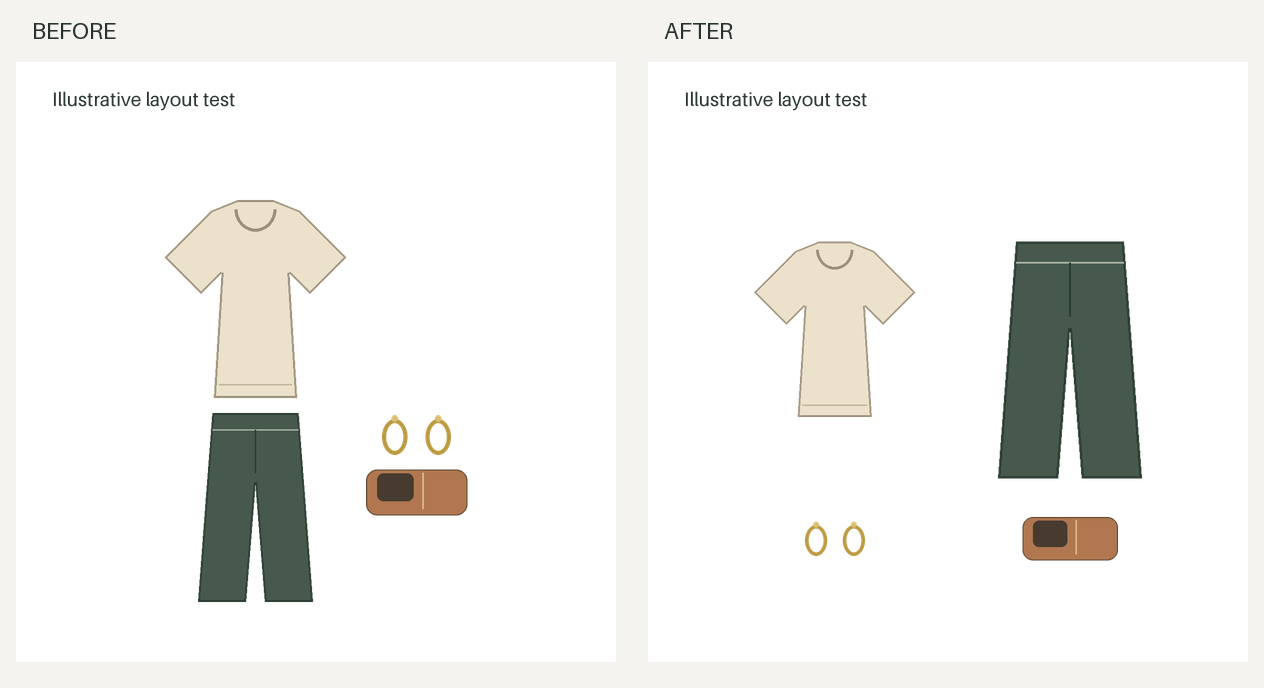

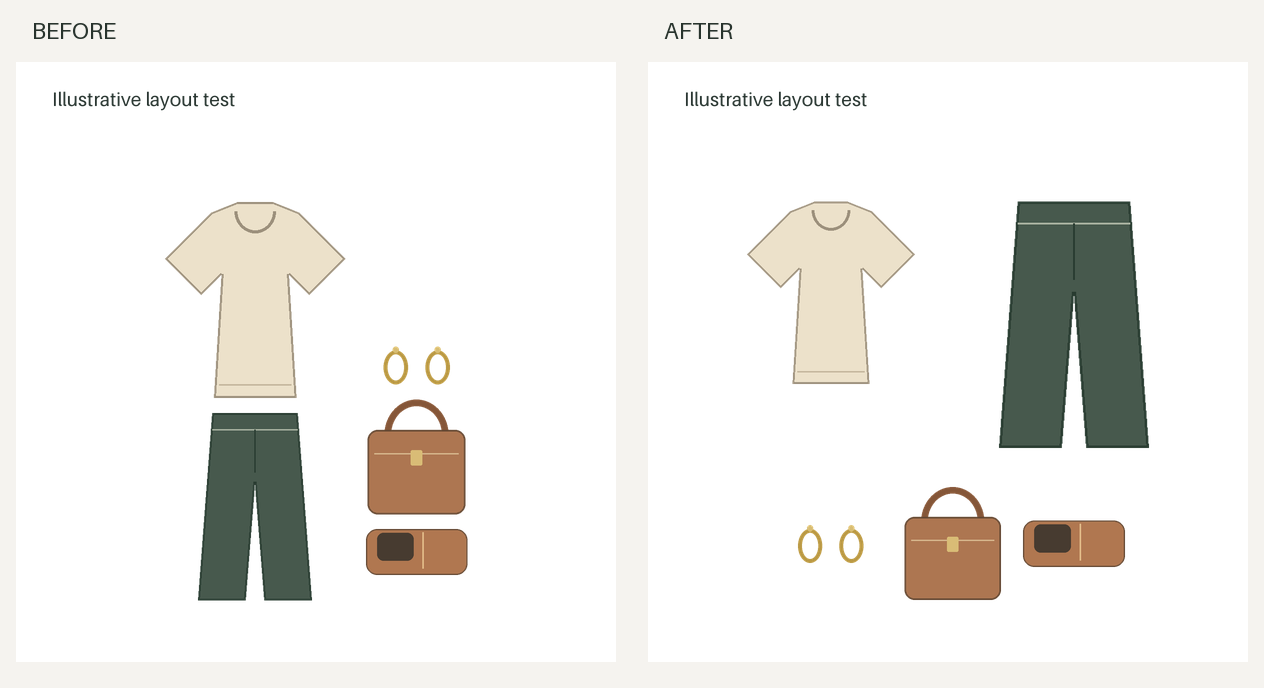

{
  "collage_score": 77.10246495500283,
  "visual_balance_score": 23.272329894004848,
  "category_layout_score": 24.999999999999968,
  "overlap_penalty": -0.0,
  "empty_space_penalty": -1.1698649390019915,
  "hero_item_prominence": 30,
  "measurements": {
    "visual_centroid": [
      0.5681248512665795,
      0.5066433248154848
    ],
    "group_occupancy": 0.3915060301676353,
    "largest_internal_empty_rectangle": 0.2336950314106225,
    "nearest_item_gaps": [
      0.13733232051110988,
      0.06459983510149875,
      0.17476198888111066,
      0.06459983510149875
    ],
    "support_pair_gaps": [
      0.17476198888111066,
      0.06459983510149875
    ],
    "overlap_pairs": [],
    "visible_item_areas": {
      "tops": 0.04365762867647059,
      "bottoms": 0.07712928921568628,
      "accessories": 0.001649203431372549,
      "shoes": 0.011455882352941175
    },
    "board_row_gap": 0.06459983510149869,
    "board_column_gap": 0.13733232051110988,
    "layout_family": "approved_

In [8]:
baseline = compose(outfit, OUT/'baseline.png', candidates=1,
    title='Illustrative layout test', manifest_path=OUT/'demo_manifest.csv', config=CONFIG)
demo_reports = {}
for name, selected_outfit in [('no_bag', outfit), ('with_bag', full_demo)]:
    report = compare_outfit(selected_outfit, OUT/name, OUT/'demo_manifest.csv',
                           title='Illustrative layout test', candidates=100, config=CONFIG)
    demo_reports[name] = report
    display(Image.open(OUT/name/'comparison.png'))
result = json.loads((OUT/'no_bag'/'after.json').read_text(encoding='utf-8'))
print(json.dumps(result['score'], indent=2))

## 5. Dress and outerwear

A dress replaces the top and bottom and uses an alternative template. For separates with a coat, keep the two columns and draw outerwear behind the top.

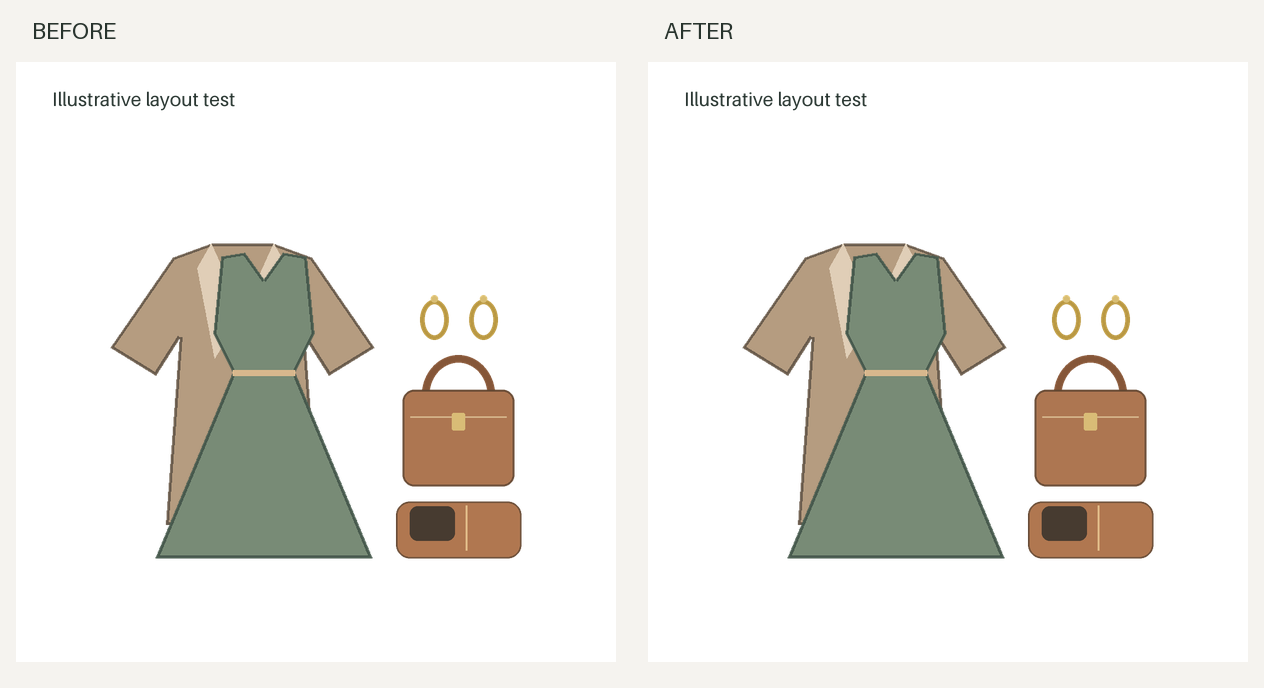

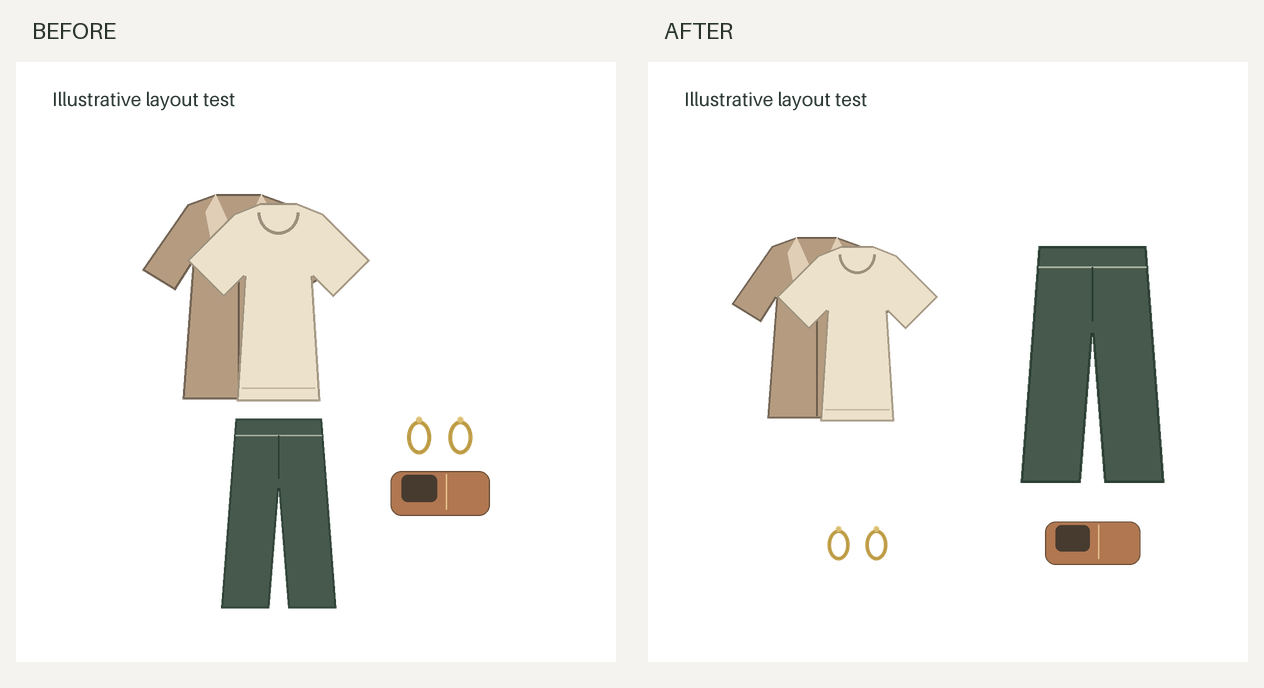

In [9]:
for name, categories in [
    ('dress_coat', ('dresses','outerwear','bags','shoes','accessories')),
    ('separates_coat', ('tops','bottoms','outerwear','shoes','accessories')),
]:
    layered = {'items': {c:{'product_id':c} for c in categories},
               'provenance': 'Schematic demo; not real products'}
    report = compare_outfit(layered, OUT/name, OUT/'demo_manifest.csv',
                           title='Illustrative layout test', config=CONFIG)
    demo_reports[name] = report
    display(Image.open(OUT/name/'comparison.png'))

## 6. Real-data integration

Render the saved real Week 6 outfit using your Week 3 manifest and cutouts. Compare both layouts without changing products; real rendering is skipped if the manifest is unavailable.

{
  "index": 1,
  "status": "rendered",
  "report": {
    "measurements": {
      "before": {
        "shoe_width_px": 199,
        "shoe_height_px": 102,
        "accessory_shoe_gap_px": 28.844363477094387,
        "collage_score": 73.3201475325563
      },
      "after": {
        "shoe_width_px": 218,
        "shoe_height_px": 112,
        "accessory_shoe_gap_px": 249.83119758783238,
        "collage_score": 77.49102812075826
      }
    },
    "input_image_sha256": {
      "117635100": "d18a1129053706b7157ddffe27ceb02db72c45cdccca0404e07d07c8f65b198b",
      "143634795": "2a5901e47c2fad3b2761b39956e72d8f8a8feda78085db9a727a806e0bda2361",
      "119664180": "d10e2ffd19e950ed6794e48da8e249e046ee7127705c271454158752182a424d",
      "123260132": "bbcea4a02de363ffbed22f50cea1570961f4ed6e116a2eb0edc79f3112b8abbb"
    },
    "same_products": true,
    "same_title": "Summer dinner",
    "same_canvas_size": 1200,
    "score_note": "Old and new scores use different objectives: do not compare

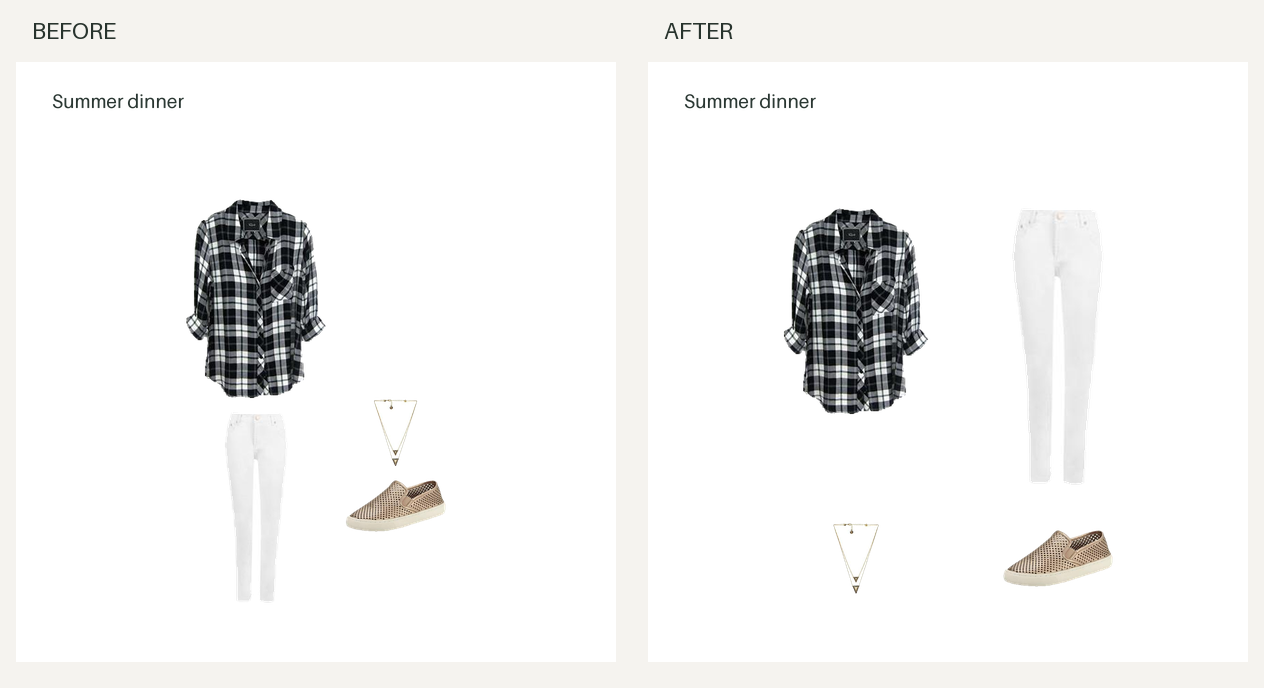

37

In [10]:
saved_real_outfit = {'rank': 1, 'items': {'tops': {'product_id': '117635100', 'title': 'rails hunter plaid shirt in pine/white'}, 'bottoms': {'product_id': '143634795', 'title': 'wearall plus size skinny leg jeans'}, 'shoes': {'product_id': '123260132', 'title': 'a stylish pair of shoes: tory burch jesse perforated slip-on'}, 'accessories': {'product_id': '119664180', 'title': 'a stylish pair of accessories: house harlow teepee triangle necklace'}}, 'total_price': 154.49, 'score': 8.534, 'score_breakdown': {'item_relevance': 0.562, 'category_completeness': 1.0, 'color_compatibility': 1.0, 'style_compatibility': 1.0, 'occasion_compatibility': 1.0, 'season_compatibility': 1.0, 'existing_outfit_evidence': 0.167, 'price_efficiency': 0.564, 'duplicate_penalty': 0.0}, 'reasons': ['complete required slots', 'compatible color palette', 'compatible product styles', 'fits summer dinner', 'fits summer', 'supported by existing outfit relationships'], 'provenance': {'source_notebook': 'candidate_outfit_construction.ipynb', 'cell_index': 39, 'output': 'first TOP OUTFITS JSON object, rank 1', 'query': 'I want something elegant but not too formal for a summer dinner.', 'note': 'Real IDs and titles from saved Week 6 output; matching Week 3 cutouts not available locally.'}}
MANIFEST = Path('/content/drive/MyDrive/polyvore_segmented_cache/segmentation_manifest.csv')
CUTOUT_OVERRIDE = None
WEEK6_EXPORT = None
real_outfits = [saved_real_outfit]
if WEEK6_EXPORT is not None:
    exported = json.loads(Path(WEEK6_EXPORT).read_text(encoding='utf-8-sig'))
    extra = exported.get('top_outfits', [exported]) if isinstance(exported, dict) else exported
    if not isinstance(extra, list):
        raise ValueError('Expected one outfit, a list, or top_outfits')
    seen = {tuple(sorted(str(p['product_id']) for p in saved_real_outfit['items'].values()))}
    for other in extra:
        signature = tuple(sorted(str(p['product_id']) for p in other['items'].values()))
        if signature not in seen:
            real_outfits.append(other)
            seen.add(signature)
if MANIFEST.is_file():
    real_reports = evaluate_real_outfits(real_outfits, MANIFEST, OUT/'real',
                                        cutout_dir=CUTOUT_OVERRIDE, config=CONFIG)
    for report in real_reports:
        print(json.dumps(report, indent=2))
        if report['status'] == 'rendered':
            display(Image.open(OUT/'real'/f"outfit_{report['index']:02}"/'comparison.png'))
    real_status = {'requested':len(real_outfits),
                   'rendered':sum(r['status']=='rendered' for r in real_reports)}
else:
    real_status = {'status':'not_run','reason':'Source Week 3 manifest/cutouts unavailable'}
    print('Real comparison not run: connect the Week 3 source files. Demo images are illustrative only.')
(OUT/'real_evaluation_status.json').write_text(json.dumps(real_status, indent=2), encoding='utf-8')

## 7. Scoring and checks

The score combines balance, category placement, overlap and spacing penalties, and garment prominence. Run checks for the approved positions, transparency, proportions, overlap, and reproducible search.

In [11]:
import csv
import itertools
import json
import random
import tempfile
import unittest
from copy import deepcopy
from pathlib import Path
from PIL import Image, ImageChops, ImageDraw
import types
collage = types.SimpleNamespace(**globals())


class TwoColumnTests(unittest.TestCase):
    def setUp(self):
        self.tmp = tempfile.TemporaryDirectory()
        self.addCleanup(self.tmp.cleanup)
        self.folder = Path(self.tmp.name)

    def outfit(self, categories):
        dims = {'tops':(210,310),'bottoms':(100,360),'shoes':(300,140),
                'accessories':(95,150),'bags':(180,220),'outerwear':(310,400),'dresses':(210,390)}
        outfit = {'items':{}}
        for cat in categories:
            w,h = dims[cat]
            img = Image.new('RGBA',(w+20,h+20))
            ImageDraw.Draw(img).ellipse((10,10,w+9,h+9),fill='#697b62')
            path=self.folder/f'{cat}.png'; img.save(path)
            outfit['items'][cat]={'product_id':cat,'cutout_path':str(path)}
        return outfit

    def render(self, outfit, **kwargs):
        return collage.compose(outfit,self.folder/'collage.png',size=400,**kwargs)

    def assert_board(self, placements):
        p={v['category']:v for v in placements}
        center=lambda v:v['x']+v['width']/2
        self.assertLess(p['tops']['x']+p['tops']['width'],p['bottoms']['x'])
        self.assertAlmostEqual(p['tops']['y'],p['bottoms']['y'])
        self.assertGreaterEqual(p['bottoms']['height']+1e-9,1.15*p['tops']['height'])
        for cat,parent in [('shoes','bottoms'),('accessories','tops')]:
            if cat in p:
                self.assertAlmostEqual(center(p[cat]),center(p[parent]))
                self.assertGreater(p[cat]['y'],max(p['tops']['y']+p['tops']['height'],
                                                  p['bottoms']['y']+p['bottoms']['height'])+.025)

    def test_all_candidates_obey_approved_structure(self):
        outfit=self.outfit(['tops','bottoms','shoes','accessories'])
        items=collage.load_items(outfit); cfg=collage.LayoutConfig(); rng=random.Random(7)
        templates=collage.available_templates(items)
        self.assertTrue(all(t.startswith('board_') for t in templates))
        for n in range(60):
            p=collage._placements(items,templates[n%len(templates)],rng,cfg,n<3)
            self.assert_board(p)
            self.assertEqual(collage.validate_layout(items,p,400,cfg),[])

    def test_missing_categories_bags_and_coats(self):
        for flags in itertools.product((False,True),repeat=3):
            cats=['tops','bottoms','shoes']+[c for c,yes in zip(['accessories','bags','outerwear'],flags) if yes]
            with self.subTest(categories=cats):
                result=self.render(self.outfit(cats),candidates=1)
                self.assert_board(result['placements'])
                self.assertEqual({p['category'] for p in result['placements']},set(cats))
                self.assertEqual(result['validation_errors'],[])

    def test_old_layout_rejected_and_scores_worse(self):
        outfit=self.outfit(['tops','bottoms','shoes','accessories'])
        items=collage.load_items(outfit)
        good=self.render(outfit,candidates=1)
        broken=deepcopy(good['placements'])
        p={v['category']:v for v in broken}
        p['bottoms']['x']=p['tops']['x']; p['bottoms']['y']=p['tops']['y']+.30
        p['shoes']['x']=p['accessories']['x']
        errors=collage.validate_layout(items,broken,400)
        self.assertTrue(any('Board' in e or 'beneath' in e for e in errors))
        self.assertLess(collage.score_layout(items,broken)['category_layout_score'],good['score']['category_layout_score'])

    def test_reproducible_search_and_score_sum(self):
        outfit=self.outfit(['tops','bottoms','shoes','accessories'])
        a=self.render(outfit,candidates=50,seed=19)
        b=self.render(outfit,candidates=50,seed=19)
        self.assertEqual(a,b)
        self.assertGreaterEqual(a['score']['collage_score'],a['baseline_score'])
        self.assertAlmostEqual(a['score']['collage_score'],sum(a['score'][k] for k in collage.COMPONENTS))
        self.assertLessEqual(a['score']['overlap_penalty'],0)
        self.assertLessEqual(a['score']['empty_space_penalty'],0)

    def test_transparency_proportions_bounds_and_overlap(self):
        outfit=self.outfit(['tops','bottoms','shoes','accessories'])
        result=self.render(outfit,candidates=1,title='')
        items=collage.load_items(outfit)
        with Image.open(self.folder/'collage.png') as image:
            self.assertEqual(image.mode,'RGBA'); self.assertEqual(image.getpixel((0,0))[3],0)
            for item,p in zip(items,result['placements']):
                x,y,w,h=p['pixel_box_xywh']
                self.assertGreaterEqual(x,0); self.assertGreaterEqual(y,52)
                self.assertLessEqual(x+w,400); self.assertLessEqual(y+h,400)
                self.assertAlmostEqual(p['width']/p['height'],item.image.width/item.image.height)
                expected=item.image.resize((w,h),Image.Resampling.LANCZOS).getchannel('A')
                actual=image.crop((x,y,x+w,y+h)).getchannel('A')
                self.assertIsNone(ImageChops.difference(actual,expected).getbbox())
        self.assertEqual(json.loads((self.folder/'collage.json').read_text()),result)
        self.assertEqual(result['score']['measurements']['overlap_pairs'],[])

    def test_spacing_configuration_and_smaller_supports(self):
        outfit=self.outfit(['tops','bottoms','shoes','accessories'])
        a=self.render(outfit,candidates=1)
        b=self.render(outfit,candidates=1,config=collage.LayoutConfig(board_row_gap=.095,board_column_gap=.20))
        self.assertGreater(b['score']['measurements']['board_row_gap'],a['score']['measurements']['board_row_gap'])
        self.assertGreater(b['score']['measurements']['board_column_gap'],a['score']['measurements']['board_column_gap'])
        p={v['category']:v for v in a['placements']}
        self.assertLess(p['shoes']['width'],.22)
        self.assertLess(p['accessories']['height'],p['tops']['height'])
        self.assertGreater(collage._box_gap(p['shoes'],p['accessories']),.1)

    def test_alternative_templates_remain_valid(self):
        for cats in (['dresses','outerwear','bags','shoes','accessories'],['tops','shoes'],['shoes'],['bags','accessories']):
            with self.subTest(categories=cats):
                outfit=self.outfit(cats)
                result=self.render(outfit,candidates=50)
                self.assertFalse(result['selected_template'].startswith('board_'))
                self.assertEqual(result['validation_errors'],[])
                self.assertEqual(len(result['placements']),len(cats))



suite = unittest.defaultTestLoader.loadTestsFromTestCase(TwoColumnTests)
test_result = unittest.TextTestRunner(verbosity=1).run(suite)
assert test_result.wasSuccessful()

.......
----------------------------------------------------------------------
Ran 7 tests in 7.272s

OK
